# C180 - Part A: The Power of Diffusion Models!


I saw the provided notebook too late, that's why I haven't used it for Part A.

# Imports

In [ ]:
from huggingface_hub import login
from google.colab import userdata
HF_TOKEN = userdata.get('HF')

login(token=HF_TOKEN)

print("Logged into Hugging Face.")


Logged into Hugging Face.


In [ ]:
import torch

SEED = 13
print("Using random seed:", SEED)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using random seed: 13
Using device: cuda


In [ ]:
EMBEDDINGS_PATH = "prompt_embeds_dict.pth"

prompt_dict = torch.load(EMBEDDINGS_PATH, map_location=DEVICE)
print("Loaded prompts:")
for k in prompt_dict.keys():
    print(" -", k)



Loaded prompts:
 - UC Berkeley's campanile tower next to the smaller Hoover tower
 - a snowy Golden Gate Bridge in San Francisco
 - a plane taking off for Christmas holidays
 - a high quality picture
 - a high quality photo
 - 


# Part 0: Setup


In [ ]:
from diffusers import DiffusionPipeline

stage_1 = DiffusionPipeline.from_pretrained(
    "DeepFloyd/IF-I-L-v1.0",
    text_encoder=None,
    variant="fp16",
    torch_dtype=torch.float16,
)
stage_1 = stage_1.to(DEVICE)

stage_2 = DiffusionPipeline.from_pretrained(
                "DeepFloyd/IF-II-L-v1.0",
                text_encoder=None,
                variant="fp16",
                torch_dtype=torch.float16,
)
stage_2 = stage_2.to(DEVICE)

print("Loaded DeepFloyd IF Stage I and II.")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/604 [00:00<?, ?B/s]


A mixture of fp16 and non-fp16 filenames will be loaded.
Loaded fp16 filenames:
[text_encoder/model.fp16-00001-of-00002.safetensors, text_encoder/model.safetensors.index.fp16.json, unet/diffusion_pytorch_model.fp16.safetensors, text_encoder/pytorch_model.bin.index.fp16.json, text_encoder/model.fp16-00002-of-00002.safetensors, safety_checker/model.fp16.safetensors]
Loaded non-fp16 filenames:
[watermarker/diffusion_pytorch_model.safetensors
If this behavior is not expected, please check your folder structure.


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

watermarker/diffusion_pytorch_model.safe(…):   0%|          | 0.00/15.5k [00:00<?, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/2.49G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loaded DeepFloyd IF Stage I and II.


torch.Size([1, 77, 4096])


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

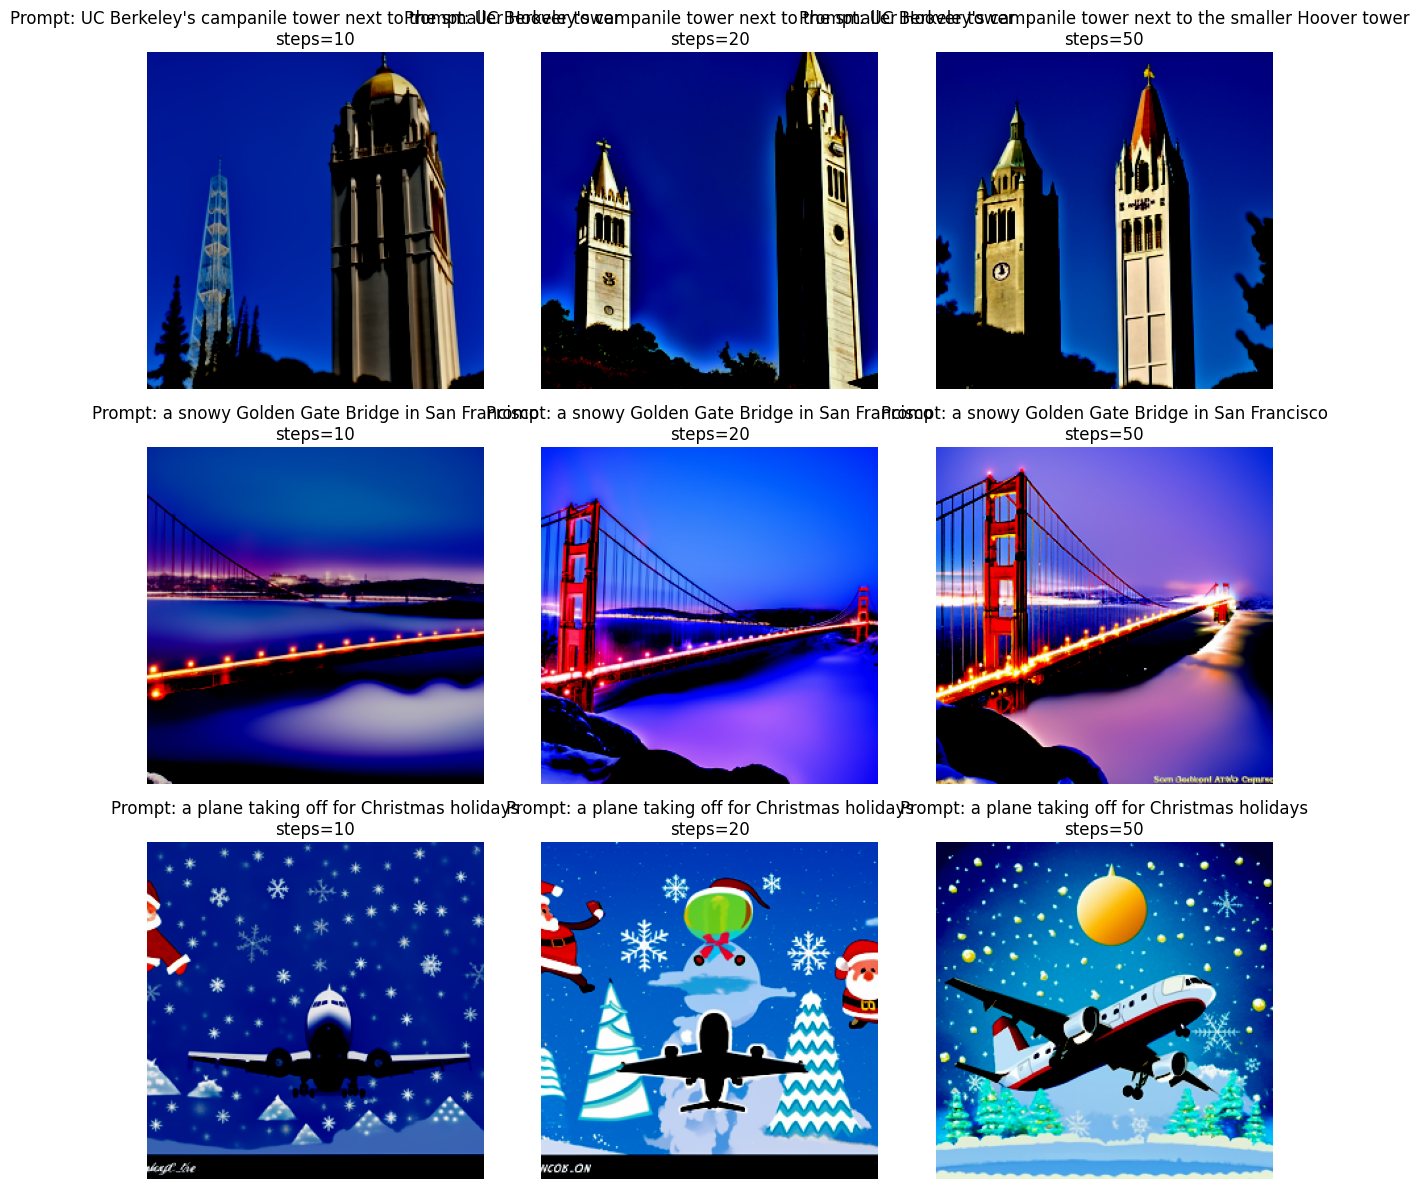

In [ ]:
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

# Choose 3 prompt keys that exist in your `prompt_dict`
PROMPTS_TO_USE = [
  "UC Berkeley's campanile tower next to the smaller Hoover tower",
  "a snowy Golden Gate Bridge in San Francisco",
  "a plane taking off for Christmas holidays"
]

# Two different inference step settings to compare
INFERENCE_STEPS_LIST = [10, 20, 50]  # You can adjust these

results = []

for prompt in PROMPTS_TO_USE:
    embedding = prompt_dict[prompt].to(DEVICE)
    print(embedding.shape)

    # Ensure shape is (batch, seq_len, hidden)
    if embedding.ndim == 2:  # (seq, hidden)
        prompt_embeds = embedding.unsqueeze(0)
    elif embedding.ndim == 3:  # already (batch, seq, hidden)
        prompt_embeds = embedding
    else:
        raise ValueError(f"Unexpected embedding shape: {embedding.shape}")f
    negative_prompt_embeds = prompt_dict['']

    for steps in INFERENCE_STEPS_LIST:
        # Stage I: generate 64x64 (or similar) latent / small image
        out_1 = stage_1(
            prompt_embeds=prompt_embeds,
            negative_prompt_embeds=negative_prompt_embeds,
            num_inference_steps=steps,
            generator=torch.manual_seed(SEED),
            output_type="pt",
        )
        lowres = out_1.images

        # Stage II: upsample to higher resolution
        # Since text_encoder=None, we need to provide negative_prompt_embeds
        # Create negative embeddings (zeros) matching the shape of positive embeddings


        out_2 = stage_2(
            image=lowres,
            prompt_embeds=prompt_embeds,
            negative_prompt_embeds=negative_prompt_embeds,
            num_inference_steps=steps,
            generator=torch.manual_seed(SEED),
            output_type="pt",
        )
        img = out_2.images[0].cpu().clamp(0, 1)

        results.append({
            "prompt": prompt,
            "steps": steps,
            "image": img,
        })

        # Free GPU memory after each generation (helps prevent OOM errors)
        if torch.cuda.is_available():
            del out_1, out_2, lowres
            torch.cuda.empty_cache()

# Display the images
n = len(results)
cols = len(INFERENCE_STEPS_LIST)
rows = max(1, n // cols)
plt.figure(figsize=(4 * cols, 4 * rows))

for i, res in enumerate(results):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(to_pil_image(res["image"]))
    plt.axis("off")
    plt.title(f"Prompt: {res['prompt']}\nsteps={res['steps']}")

plt.tight_layout()
plt.show()



In [ ]:
import os


output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)

for res in results:
    prompt = res["prompt"]
    steps = res["steps"]

    prompt_slug = "".join(c if c.isalnum() or c in (' ', '_', '-') else '_' for c in prompt)[:50].strip().replace(" ", "_")
    filename = f"prompt_{prompt_slug}_steps_{steps}.png"
    filepath = os.path.join(output_dir, filename)
    to_pil_image(res["image"]).save(filepath)
    print(f"Saved image to {filepath}")

Saved image to generated_images/prompt_UC_Berkeley_s_campanile_tower_next_to_the_smaller_steps_10.png
Saved image to generated_images/prompt_UC_Berkeley_s_campanile_tower_next_to_the_smaller_steps_20.png
Saved image to generated_images/prompt_UC_Berkeley_s_campanile_tower_next_to_the_smaller_steps_50.png
Saved image to generated_images/prompt_a_snowy_Golden_Gate_Bridge_in_San_Francisco_steps_10.png
Saved image to generated_images/prompt_a_snowy_Golden_Gate_Bridge_in_San_Francisco_steps_20.png
Saved image to generated_images/prompt_a_snowy_Golden_Gate_Bridge_in_San_Francisco_steps_50.png
Saved image to generated_images/prompt_a_plane_taking_off_for_Christmas_holidays_steps_10.png
Saved image to generated_images/prompt_a_plane_taking_off_for_Christmas_holidays_steps_20.png
Saved image to generated_images/prompt_a_plane_taking_off_for_Christmas_holidays_steps_50.png


# Part 1: Sampling Loops


## 1.1 Implementing the Forward Process

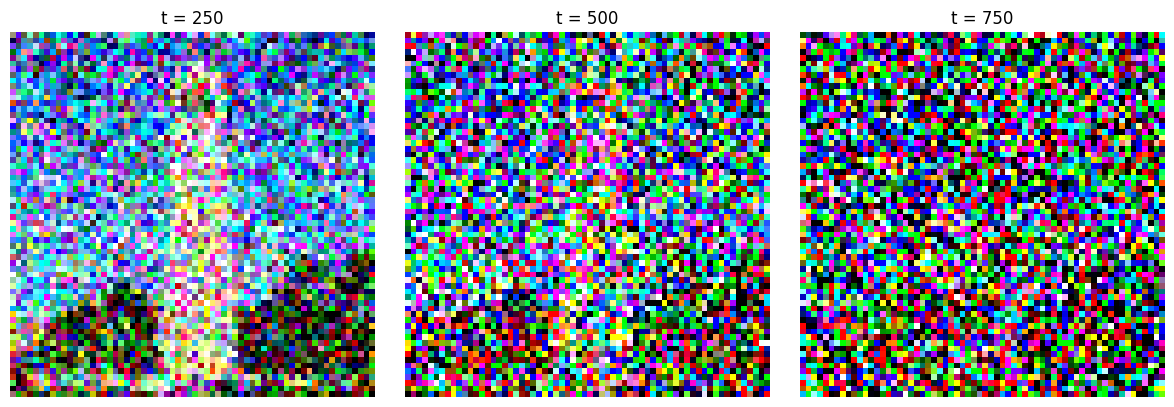

In [ ]:

import math
from PIL import Image
import torchvision.transforms as T
import torch
import matplotlib.pyplot as plt


alphas_cumprod = stage_1.scheduler.alphas_cumprod

def forward(im: torch.Tensor, t: int) -> torch.Tensor:
    """Apply the forward diffusion process q(x_t | x_0).

    Args:
        im: clean image tensor of shape (C, H, W) or (B, C, H, W), values in [0, 1].
        t: integer timestep in [0, T_STEPS-1].

    Returns:
        noisy_im: noisy image at timestep t, same shape as `im`.
    """
    # Ensure tensor is on the correct device
    im = im.to(DEVICE)

    # Get \bar{alpha}_t scalar
    alpha_bar_t = alphas_cumprod[t].to(DEVICE)

    # Make sure it broadcasts over image dimensions
    # For a scalar alpha_bar_t and image tensor `im`, this already broadcasts correctly.
    noise = torch.randn_like(im)
    noisy_im = torch.sqrt(alpha_bar_t) * im + torch.sqrt(1.0 - alpha_bar_t) * noise
    return noisy_im


# Load and preprocess the Campanile image
campanile_path = "campanile.jpg"  # already in this folder
pil_img = Image.open(campanile_path).convert("RGB")

transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),  # yields values in [0, 1]
])

clean_im = transform(pil_img).to(DEVICE)

# Visualize the forward process at selected timesteps
noise_levels = [250, 500, 750]
noisy_imgs = []
for t in noise_levels:
    noisy = forward(clean_im, t).cpu().clamp(0.0, 1.0)
    noisy_imgs.append(noisy)

plt.figure(figsize=(12, 4))
for i, (t, img_t) in enumerate(zip(noise_levels, noisy_imgs)):
    plt.subplot(1, len(noise_levels), i + 1)
    plt.imshow(img_t.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"t = {t}")

plt.tight_layout()
plt.show()



In [ ]:
import os
from torchvision.transforms.functional import to_pil_image

output_dir_noisy = "noisy_images"
os.makedirs(output_dir_noisy, exist_ok=True)

for i, (t, img) in enumerate(zip(noise_levels, noisy_imgs)):
    filename = f"noisy_t_{t}.png"
    filepath = os.path.join(output_dir_noisy, filename)
    to_pil_image(img).save(filepath)
    print(f"Saved noisy image for t={t} to {filepath}")

Saved noisy image for t=250 to noisy_images/noisy_t_250.png
Saved noisy image for t=500 to noisy_images/noisy_t_500.png
Saved noisy image for t=750 to noisy_images/noisy_t_750.png


## 1.2 Classical Denoising

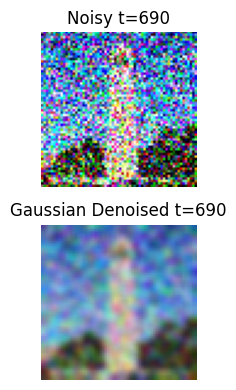

In [ ]:

from torchvision.transforms.functional import gaussian_blur

kernel_size = 5
sigma = 1.5

gaussian_denoised_imgs = []
for noisy_img in noisy_imgs:
    # Input should be torch.Tensor of shape [C, H, W]
    denoised = gaussian_blur(noisy_img, kernel_size=kernel_size, sigma=sigma)
    gaussian_denoised_imgs.append(denoised)

plt.figure(figsize=(12, 4))
for i, (t, img_t, denoised_t) in enumerate(zip(noise_levels, noisy_imgs, gaussian_denoised_imgs)):
    # Show noisy image
    plt.subplot(2, len(noise_levels), i + 1)
    plt.imshow(img_t.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"Noisy t={t}")

    # Show denoised image
    plt.subplot(2, len(noise_levels), i + 1 + len(noise_levels))
    plt.imshow(denoised_t.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"Gaussian Denoised t={t}")

plt.tight_layout()
plt.show()


In [ ]:
import os
from torchvision.transforms.functional import to_pil_image

output_dir_gaussian_denoised = "gaussian_denoised_images"
os.makedirs(output_dir_gaussian_denoised, exist_ok=True)

for i, (t, img) in enumerate(zip(noise_levels, gaussian_denoised_imgs)):
    filename = f"gaussian_denoised_t_{t}.png"
    filepath = os.path.join(output_dir_gaussian_denoised, filename)
    to_pil_image(img).save(filepath)
    print(f"Saved Gaussian denoised image for t={t} to {filepath}")

Saved Gaussian denoised image for t=250 to gaussian_denoised_images/gaussian_denoised_t_250.png
Saved Gaussian denoised image for t=500 to gaussian_denoised_images/gaussian_denoised_t_500.png
Saved Gaussian denoised image for t=750 to gaussian_denoised_images/gaussian_denoised_t_750.png


## 1.3 One-step denoising with the pretrained DeepFloyd IF UNet


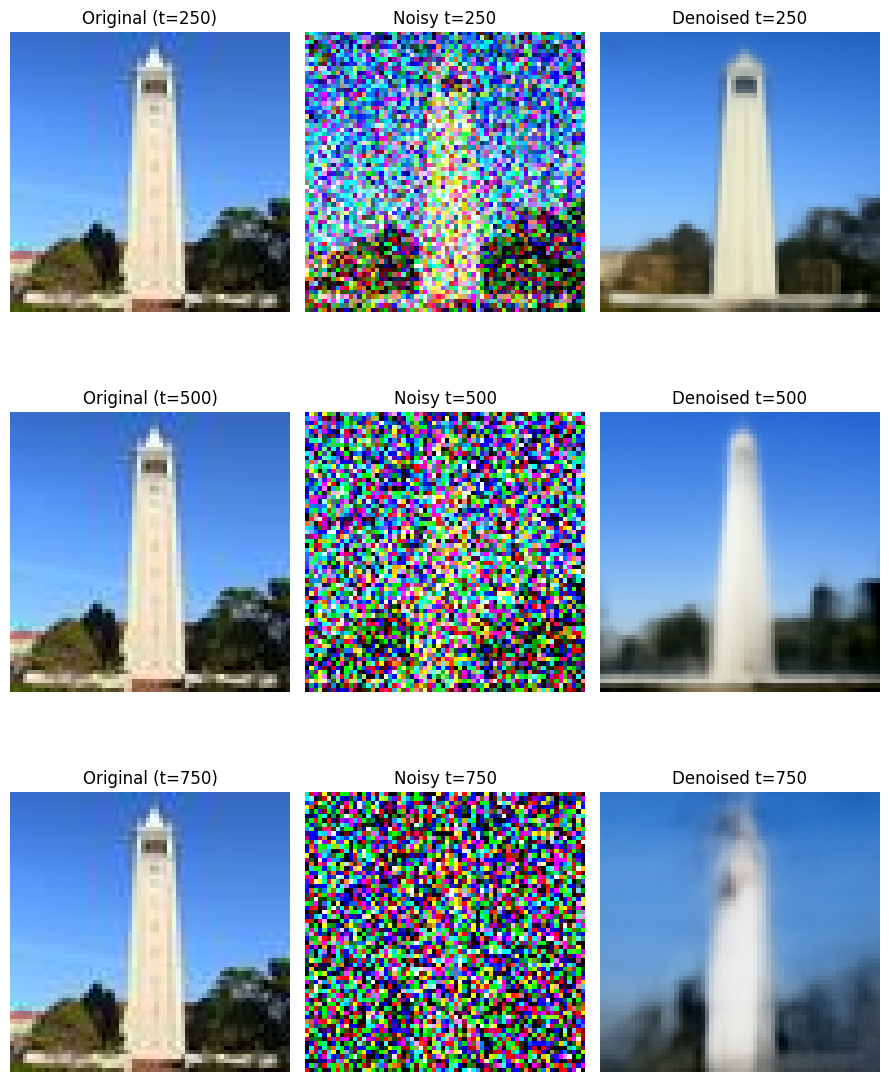

In [ ]:

import torch
import matplotlib.pyplot as plt

# We will use the prompt embedding for "a high quality photo"
prompt_key = "a high quality photo"
prompt_embeds = prompt_dict[prompt_key].to(DEVICE)

noise_levels = [250, 500, 750]
denoised_imgs = []
noisy_imgs_unet = []

with torch.no_grad():
    for t_val in noise_levels:
        # Recreate the noisy image at timestep t using our forward process
        im_noisy = forward(clean_im, t_val)  # (C, H, W)
        im_noisy = im_noisy.to(stage_1.unet.device).to(stage_1.unet.dtype)

        # Add batch dimension for UNet: (1, C, H, W)
        im_noisy_batch = im_noisy.unsqueeze(0)

        # Timestep tensor (batch size 1)
        t_tensor = torch.tensor([t_val], device=stage_1.unet.device, dtype=torch.long)

        # Predict noise with the UNet
        # Output has shape (1, 6, 64, 64); first 3 channels are the noise estimate
        eps_pred_6, = stage_1.unet(
            im_noisy_batch,
            t_tensor,
            encoder_hidden_states=prompt_embeds,
            return_dict=False,
        )
        eps_pred = eps_pred_6[:, :3, :, :]  # (1, 3, 64, 64)

        # Invert the forward process using equation A.2:
        # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps
        # => x_0_hat = (x_t - sqrt(1 - alpha_bar_t) * eps_hat) / sqrt(alpha_bar_t)
        alpha_bar_t = alphas_cumprod[t_val].to(stage_1.unet.device)
        alpha_bar_t = alpha_bar_t.view(1, 1, 1, 1).type_as(im_noisy_batch)

        x0_hat = (im_noisy_batch - torch.sqrt(1.0 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)

        # Move back to CPU for visualization
        im_noisy_cpu = im_noisy_batch.squeeze(0).detach().cpu().clamp(0.0, 1.0)
        x0_hat_cpu = x0_hat.squeeze(0).detach().cpu().clamp(0.0, 1.0)

        noisy_imgs_unet.append(im_noisy_cpu)
        denoised_imgs.append(x0_hat_cpu)

# Visualize: original, noisy, and denoised for each t
plt.figure(figsize=(9, 4 * len(noise_levels)))

for i, t_val in enumerate(noise_levels):
    # Original image (same for all t)
    plt.subplot(len(noise_levels), 3, 3 * i + 1)
    # Convert to float32 for plotting compatibility
    plt.imshow(clean_im.cpu().permute(1, 2, 0).clamp(0.0, 1.0).to(torch.float32))
    plt.axis("off")
    plt.title(f"Original (t={t_val})")

    # Noisy image at t
    plt.subplot(len(noise_levels), 3, 3 * i + 2)
    # Convert to float32 for plotting compatibility
    plt.imshow(noisy_imgs_unet[i].permute(1, 2, 0).to(torch.float32))
    plt.axis("off")
    plt.title(f"Noisy t={t_val}")

    # Denoised estimate
    plt.subplot(len(noise_levels), 3, 3 * i + 3)
    # Convert to float32 for plotting compatibility
    plt.imshow(denoised_imgs[i].permute(1, 2, 0).to(torch.float32))
    plt.axis("off")
    plt.title(f"Denoised t={t_val}")

plt.tight_layout()
plt.show()

In [ ]:
import os
from torchvision.transforms.functional import to_pil_image

output_dir_unet_denoised = "unet_denoised_images"
os.makedirs(output_dir_unet_denoised, exist_ok=True)

for i, (t, img) in enumerate(zip(noise_levels, denoised_imgs)):
    filename = f"unet_denoised_t_{t}.png"
    filepath = os.path.join(output_dir_unet_denoised, filename)
    to_pil_image(img).save(filepath)
    print(f"Saved UNet denoised image for t={t} to {filepath}")

Saved UNet denoised image for t=250 to unet_denoised_images/unet_denoised_t_250.png
Saved UNet denoised image for t=500 to unet_denoised_images/unet_denoised_t_500.png
Saved UNet denoised image for t=750 to unet_denoised_images/unet_denoised_t_750.png


## 1.4 Iterative Denoising


In [ ]:
import numpy as np
strided_timesteps= np.linspace(990, 0, 34, dtype=int)
timesteps = stage_1.scheduler.set_timesteps(timesteps=strided_timesteps)

In [ ]:
def add_variance(predicted_variance, t, image):
  '''
  Args:
    predicted_variance : (1, 3, 64, 64) tensor, last three channels of the UNet output
    t: scale tensor indicating timestep
    image : (1, 3, 64, 64) tensor, noisy image

  Returns:
    (1, 3, 64, 64) tensor, image with the correct amount of variance added
  '''
  # Add learned variance
  variance = stage_1.scheduler._get_variance(t, predicted_variance=predicted_variance)
  variance_noise = torch.randn_like(image)
  variance = torch.exp(0.5 * variance) * variance_noise
  return image + variance

In [ ]:
def iterative_denoise(im_noisy, i_start):
    im_noisy = im_noisy.to(stage_1.unet.device).to(stage_1.unet.dtype)
    im_current = im_noisy.clone().to(stage_1.unet.device).to(stage_1.unet.dtype)
    im_current = im_current.unsqueeze(0)  # Add batch dimension: (1, C, H, W)
    denoising_steps = []  # Store images for visualization

    with torch.no_grad():
        # Iterate from i_start to the end (clean image)
        for i in range(i_start, len(strided_timesteps) - 1):
            t = strided_timesteps[i]  # Current timestep (more noisy)
            t_prime = strided_timesteps[i + 1]  # Next timestep (less noisy)

            # Get alpha_bar_t
            alpha_bar_t = alphas_cumprod[t].to(stage_1.unet.device)
            alpha_bar_t = alpha_bar_t.view(1, 1, 1, 1).type_as(im_current)

            # Get alpha_bar_t_prime
            alpha_bar_t_prime = alphas_cumprod[t_prime].to(stage_1.unet.device)
            alpha_bar_t_prime = alpha_bar_t_prime.view(1, 1, 1, 1).type_as(im_current)

            # alpha_t
            alpha_t = alpha_bar_t / alpha_bar_t_prime

            beta_t = 1.0 - alpha_t

            # Prepare timestep tensor
            t_tensor = torch.tensor([t], device=stage_1.unet.device, dtype=torch.long)

            # Predict noise and variance with UNet
            # Convert prompt embeddings to model's dtype and device
            prompt_embeds = prompt_dict['a high quality picture'].to(stage_1.unet.device).to(stage_1.unet.dtype)
            model_output, = stage_1.unet(
                im_current,
                t_tensor,
                encoder_hidden_states=prompt_embeds,
                return_dict=False,
            )
            # model_output shape: (1, 6, 64, 64)
            # First 3 channels: noise estimate, last 3 channels: variance estimate
            eps_pred = model_output[:, :3, :, :]  # (1, 3, 64, 64)
            pred_var = model_output[:, 3:, :, :]

            sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
            sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)

            # One step denoising
            x0_hat = (im_current - sqrt_one_minus_alpha_bar_t * eps_pred) / sqrt_alpha_bar_t


            # Formula 3
            x_prev = (torch.sqrt(alpha_bar_t_prime) * beta_t) / (1 - alpha_bar_t) * x0_hat + (torch.sqrt(alpha_t)*(1- alpha_bar_t_prime)) / (1 - alpha_bar_t) * im_current

            x0_vis = x_prev.squeeze(0).detach().cpu().clamp(0.0, 1.0)
            plt.figure(figsize=(6, 6))
            plt.imshow(to_pil_image(x0_vis))
            plt.axis("off")
            plt.title("Final Iterative Denoised Image")
            plt.show()

            im_current = add_variance(pred_var, t, x_prev)

            # Store image for visualization (convert back to [0, 1])
            im_vis = (im_current + 1.0) / 2.0
            denoising_steps.append(im_vis.squeeze(0).detach().cpu().clamp(0.0, 1.0))

    # Final image (convert back to [0, 1])
    final_image = (im_current + 1.0) / 2.0
    final_image = final_image.squeeze(0).detach().cpu().clamp(0.0, 1.0)

    return denoising_steps, final_image

Starting timestep: 690 (index 10)
Running iterative denoising...


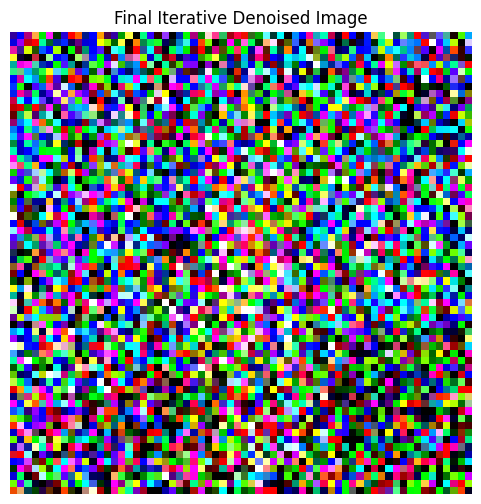

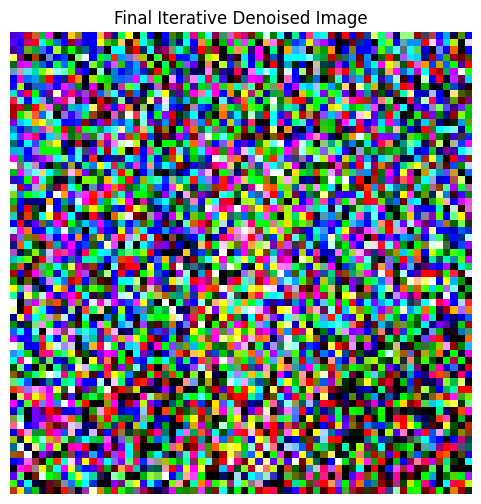

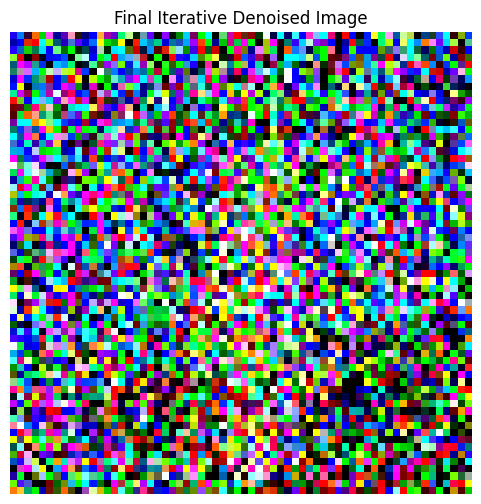

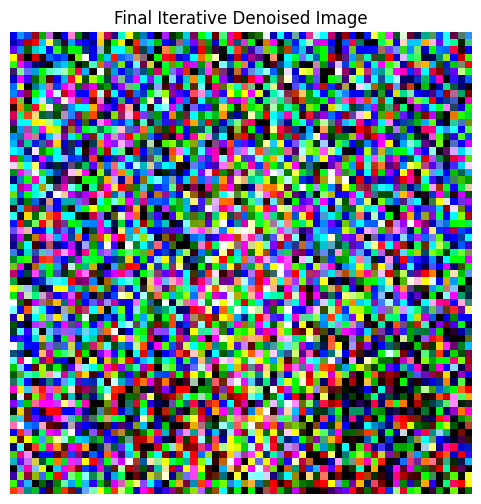

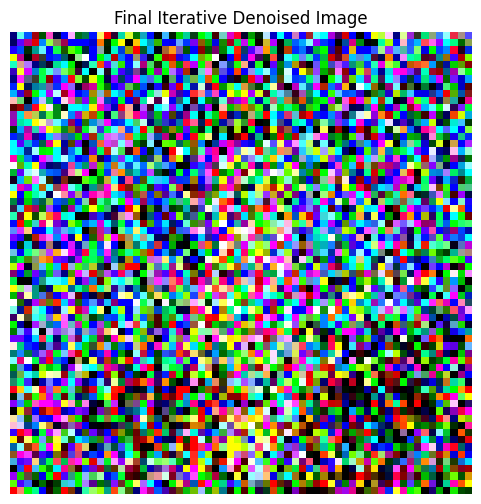

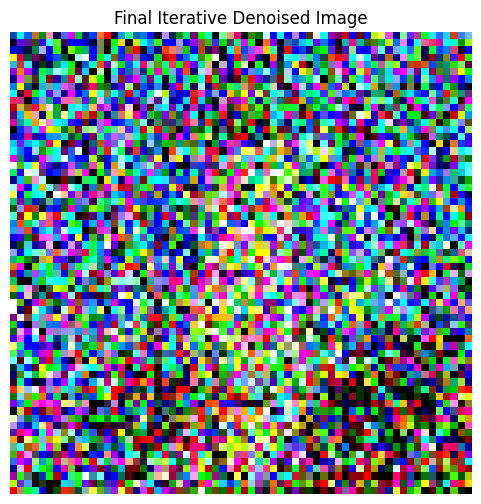

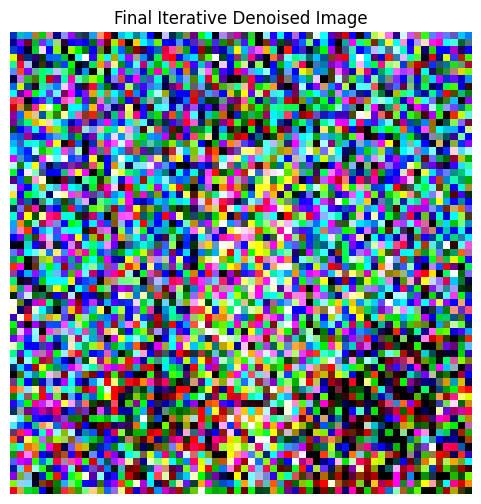

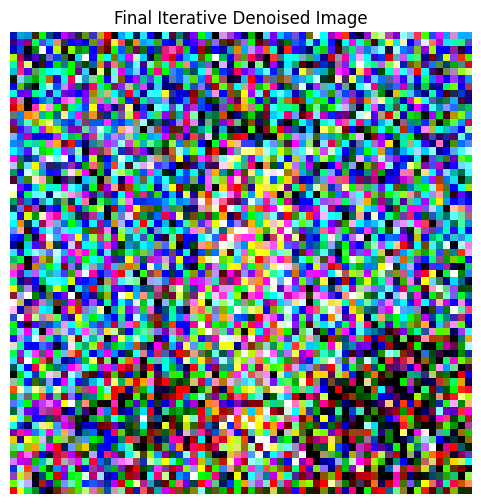

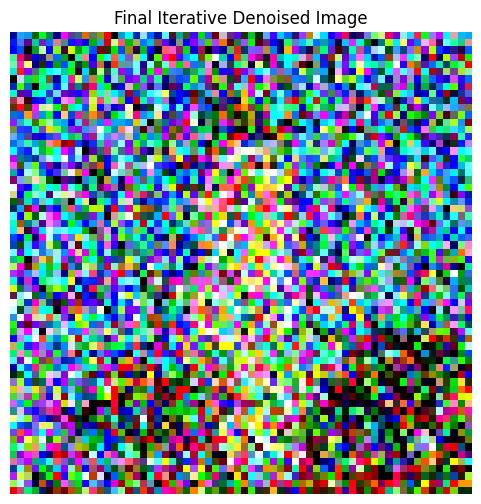

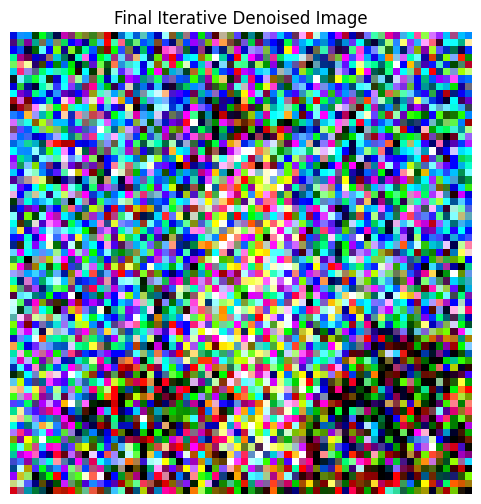

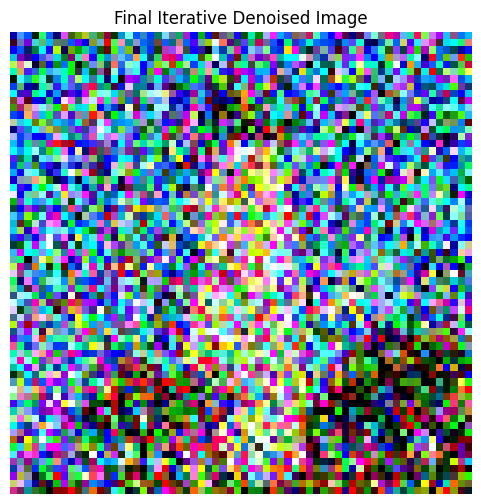

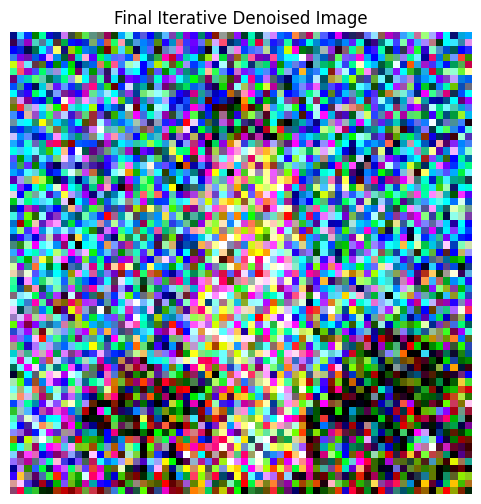

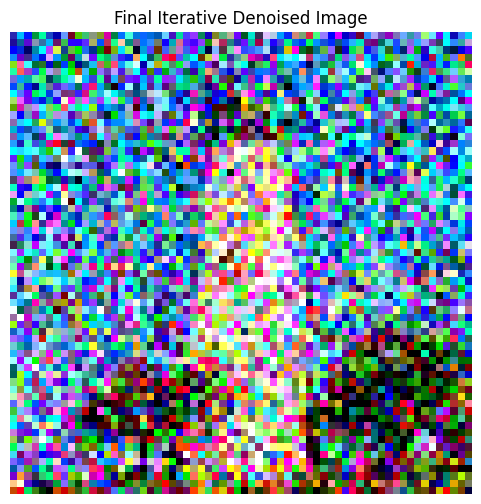

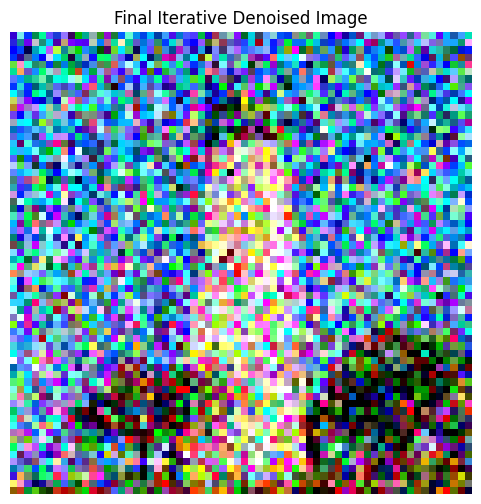

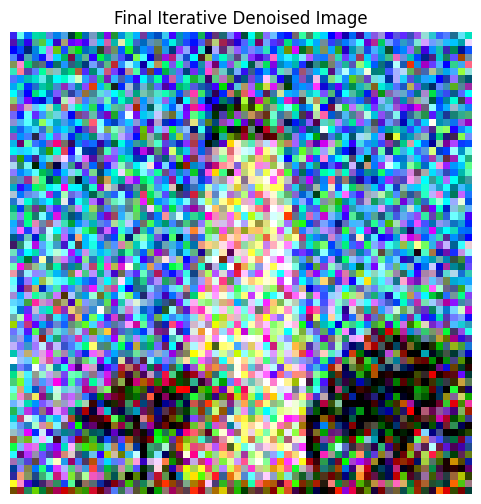

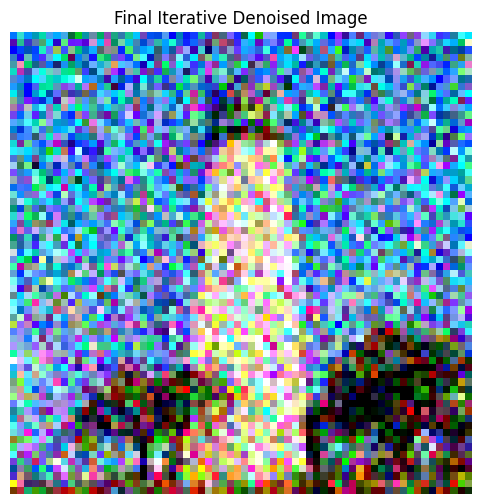

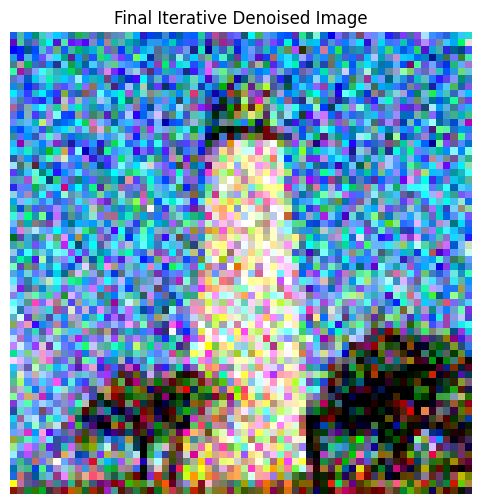

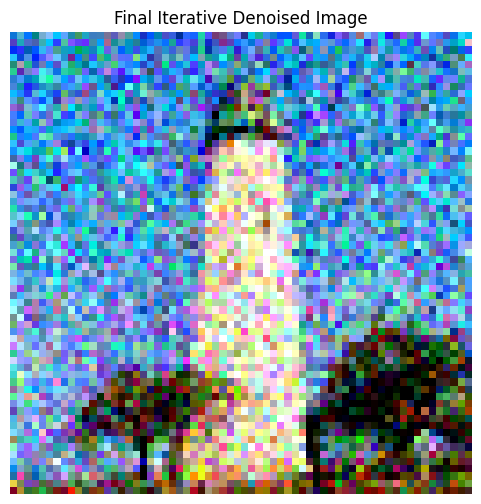

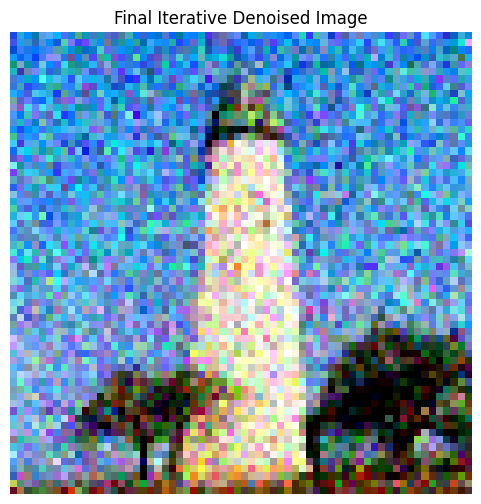

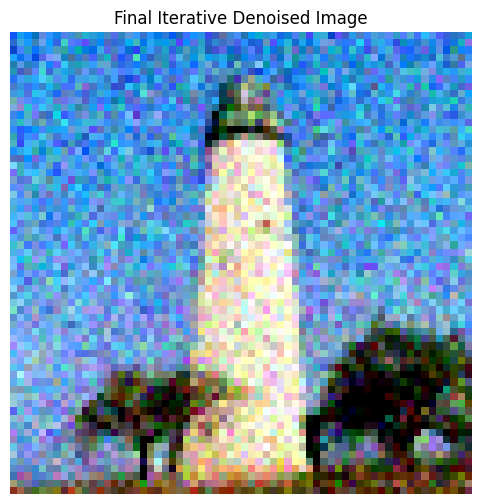

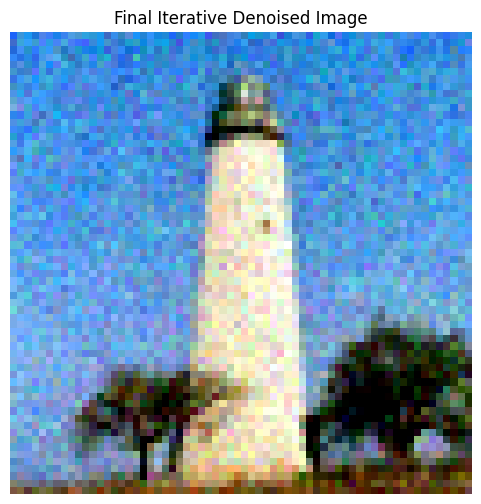

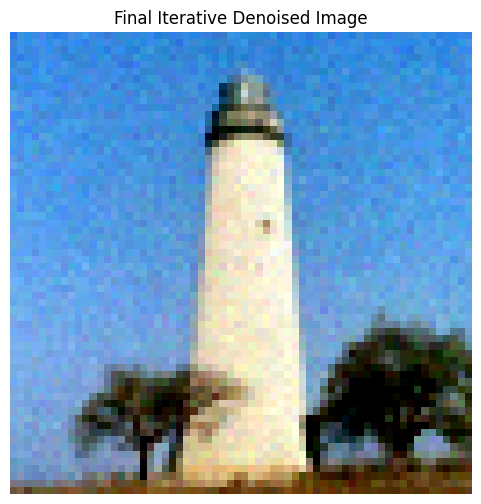

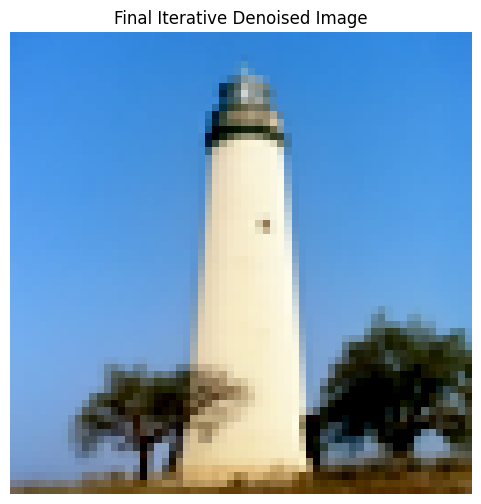

Completed 23 denoising steps


In [ ]:
# Add noise to the test image at strided_timesteps[10] and run iterative denoising

i_start = 10
t_start = strided_timesteps[i_start]
print(f"Starting timestep: {t_start} (index {i_start})")

# Add noise to clean image at timestep t_start
im_noisy_start = forward(clean_im, t_start)  # (C, H, W) in [0,1]

# Run iterative denoising
print("Running iterative denoising...")
denoising_steps, final_image_iterative = iterative_denoise(im_noisy_start, i_start)
print(f"Completed {len(denoising_steps)} denoising steps")


In [ ]:
import os
from torchvision.transforms.functional import to_pil_image

output_dir_final_iterative = "final_iterative_image"
os.makedirs(output_dir_final_iterative, exist_ok=True)

filename = "final_iterative_denoised_image.png"
filepath = os.path.join(output_dir_final_iterative, filename)
to_pil_image(final_image_iterative).save(filepath)
print(f"Saved final iterative denoised image to {filepath}")

Saved final iterative denoised image to final_iterative_image/final_iterative_denoised_image.png


Saved denoising step 0 (t=690) to iterative_denoising_steps_images/denoising_step_00_t_690.png
Saved denoising step 1 (t=540) to iterative_denoising_steps_images/denoising_step_01_t_540.png
Saved denoising step 2 (t=390) to iterative_denoising_steps_images/denoising_step_02_t_390.png
Saved denoising step 3 (t=240) to iterative_denoising_steps_images/denoising_step_03_t_240.png
Saved denoising step 4 (t=90) to iterative_denoising_steps_images/denoising_step_04_t_90.png


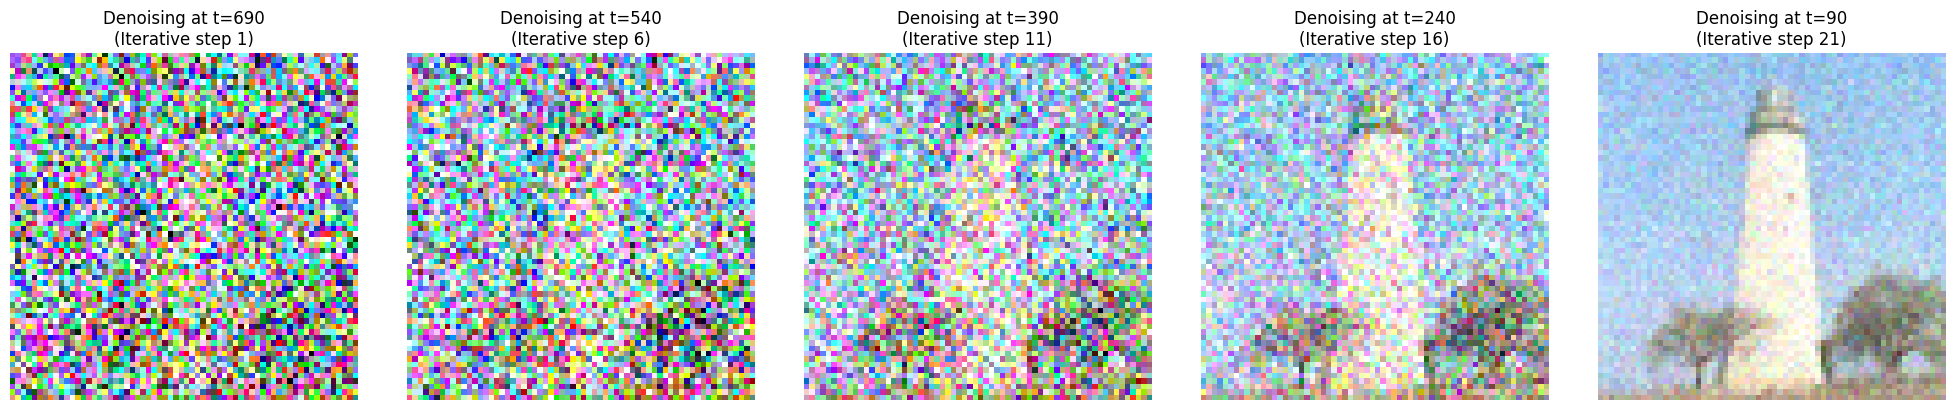

In [ ]:
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

# Display every 5th image in the denoising steps
num_steps = len(denoising_steps)
skip_interval = 5

plt.figure(figsize=(20, 4))

# Calculate how many subplots we'll have
num_plots = (num_steps // skip_interval) + (1 if num_steps % skip_interval != 0 else 0)
output_dir_denoising_steps = "iterative_denoising_steps_images"

for i, step_idx in enumerate(range(0, num_steps, skip_interval)):
    plt.subplot(1, num_plots, i + 1)
    plt.imshow(to_pil_image(denoising_steps[step_idx]))
    plt.axis("off")
    # Display the actual timestep value if available, otherwise just the step index
    # Since denoising_steps stores the images in order, we can relate it back to strided_timesteps
    # The index in denoising_steps corresponds to `i - i_start` in the iterative_denoise loop
    # So, the original t for this step_idx would be strided_timesteps[i_start + step_idx]
    actual_t_value = strided_timesteps[i_start + step_idx]
    plt.title(f"Denoising at t={actual_t_value}\n(Iterative step {step_idx + 1})")

    filename = f"denoising_step_{i:02d}_t_{actual_t_value}.png"
    filepath = os.path.join(output_dir_denoising_steps, filename)
    to_pil_image(denoising_steps[step_idx]).save(filepath)
    print(f"Saved denoising step {i} (t={actual_t_value}) to {filepath}")

plt.tight_layout()
plt.show()

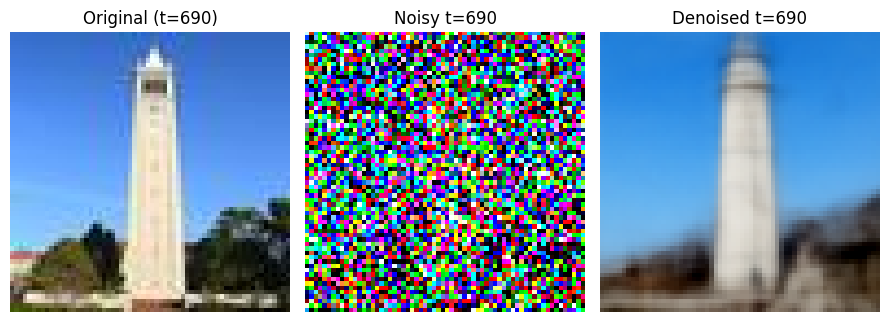

In [ ]:
## one-shot-denoising


import torch
import matplotlib.pyplot as plt

# We will use the prompt embedding for "a high quality photo"
prompt_key = "a high quality photo"
prompt_embeds = prompt_dict[prompt_key].to(DEVICE)

noise_levels = [690]
denoised_imgs = []
noisy_imgs_unet = []

with torch.no_grad():
    for t_val in noise_levels:
        # Recreate the noisy image at timestep t using our forward process
        im_noisy = forward(clean_im, t_val)  # (C, H, W)
        im_noisy = im_noisy.to(stage_1.unet.device).to(stage_1.unet.dtype)

        # Add batch dimension for UNet: (1, C, H, W)
        im_noisy_batch = im_noisy.unsqueeze(0)

        # Timestep tensor (batch size 1)
        t_tensor = torch.tensor([t_val], device=stage_1.unet.device, dtype=torch.long)

        # Predict noise with the UNet
        # Output has shape (1, 6, 64, 64); first 3 channels are the noise estimate
        eps_pred_6, = stage_1.unet(
            im_noisy_batch,
            t_tensor,
            encoder_hidden_states=prompt_embeds,
            return_dict=False,
        )
        eps_pred = eps_pred_6[:, :3, :, :]  # (1, 3, 64, 64)

        # Invert the forward process using equation A.2:
        # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps
        # => x_0_hat = (x_t - sqrt(1 - alpha_bar_t) * eps_hat) / sqrt(alpha_bar_t)
        alpha_bar_t = alphas_cumprod[t_val].to(stage_1.unet.device)
        alpha_bar_t = alpha_bar_t.view(1, 1, 1, 1).type_as(im_noisy_batch)

        x0_hat = (im_noisy_batch - torch.sqrt(1.0 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)

        # Move back to CPU for visualization
        im_noisy_cpu = im_noisy_batch.squeeze(0).detach().cpu().clamp(0.0, 1.0)
        x0_hat_cpu = x0_hat.squeeze(0).detach().cpu().clamp(0.0, 1.0)

        noisy_imgs_unet.append(im_noisy_cpu)
        denoised_imgs.append(x0_hat_cpu)

# Visualize: original, noisy, and denoised for each t
plt.figure(figsize=(9, 4 * len(noise_levels)))

for i, t_val in enumerate(noise_levels):
    # Original image (same for all t)
    plt.subplot(len(noise_levels), 3, 3 * i + 1)
    # Convert to float32 for plotting compatibility
    plt.imshow(clean_im.cpu().permute(1, 2, 0).clamp(0.0, 1.0).to(torch.float32))
    plt.axis("off")
    plt.title(f"Original (t={t_val})")

    # Noisy image at t
    plt.subplot(len(noise_levels), 3, 3 * i + 2)
    # Convert to float32 for plotting compatibility
    plt.imshow(noisy_imgs_unet[i].permute(1, 2, 0).to(torch.float32))
    plt.axis("off")
    plt.title(f"Noisy t={t_val}")

    # Denoised estimate
    plt.subplot(len(noise_levels), 3, 3 * i + 3)
    # Convert to float32 for plotting compatibility
    plt.imshow(denoised_imgs[i].permute(1, 2, 0).to(torch.float32))
    plt.axis("off")
    plt.title(f"Denoised t={t_val}")

plt.tight_layout()
plt.show()

In [ ]:
to_pil_image(denoised_imgs[0]).save("one_shot_denoising_comp_690.png")

In [ ]:
denoised_gauss = gaussian_blur(noisy_imgs_unet[0], kernel_size=kernel_size, sigma=sigma)
to_pil_image(denoised_gauss).save("denoising_gauss_comp_690.png")


## 1.5 Diffusion Model Sampling



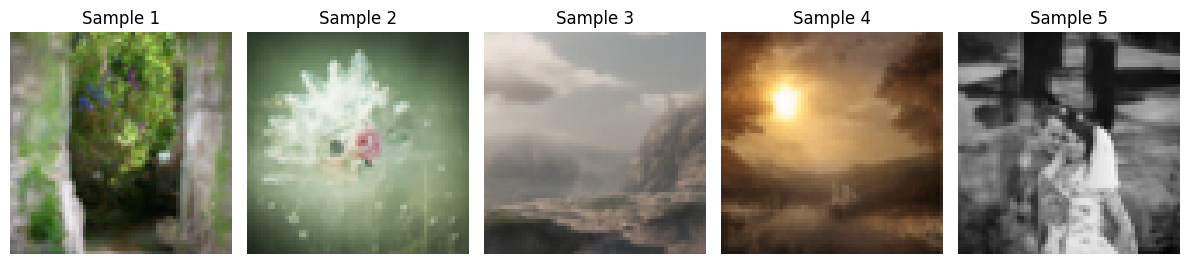

In [ ]:
# Generate 5 images from scratch using pure noise as input for "a high quality photo"
from torchvision.transforms.functional import to_pil_image

num_samples = 5
prompt = "a high quality photo"
generated_images = []

for i in range(num_samples):
    # Create pure random noise as the starting image
    im_noisy = torch.randn((3, 64, 64), dtype=torch.float16).to(DEVICE)
    i_start = 0
    # Run the iterative_denoise function to sample, using pure noise and the correct prompt
    denoising_steps = iterative_denoise(im_noisy, i_start)
    # The last step is the denoised/generated image
    generated_img = denoising_steps[-1]
    generated_images.append(generated_img)

# Show all 5 generated images
plt.figure(figsize=(12, 12 // num_samples * 1.5))
for idx, img in enumerate(generated_images):
    plt.subplot(1, num_samples, idx + 1)
    plt.imshow(to_pil_image(img))
    plt.axis("off")
    plt.title(f"Sample {idx+1}")
plt.tight_layout()
plt.show()


In [ ]:
import os
from torchvision.transforms.functional import to_pil_image

output_dir_generated = "generated_images_from_scratch"
os.makedirs(output_dir_generated, exist_ok=True)

for i, img in enumerate(generated_images):
    filename = f"generated_sample_{i+1}.png"
    filepath = os.path.join(output_dir_generated, filename)
    to_pil_image(img).save(filepath)
    print(f"Saved generated image {i+1} to {filepath}")

Saved generated image 1 to generated_images_from_scratch/generated_sample_1.png
Saved generated image 2 to generated_images_from_scratch/generated_sample_2.png
Saved generated image 3 to generated_images_from_scratch/generated_sample_3.png
Saved generated image 4 to generated_images_from_scratch/generated_sample_4.png
Saved generated image 5 to generated_images_from_scratch/generated_sample_5.png


## 1.6 Classifier-Free Guidance

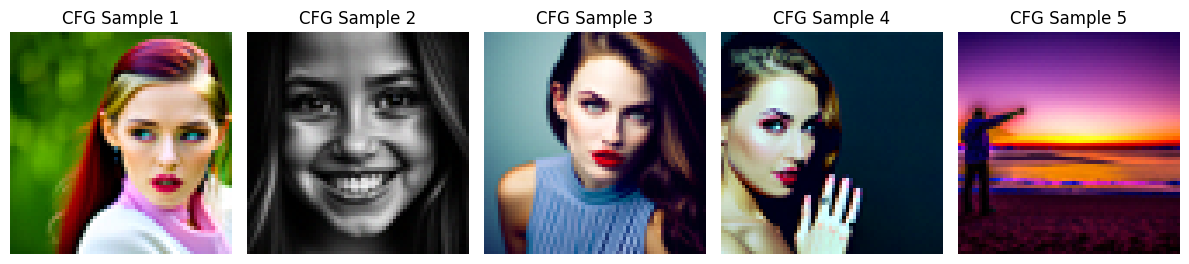

In [ ]:
import torch

def iterative_denoise_cfg(
    image_noisy,
    prompt_key,
    timesteps,
    i_start,
    cfg_scale=7.5
):
    """
    Denoising loop using Classifier-Free Guidance (CFG).

    Args:
        image_noisy: The initial noisy image (tensor).
        prompt_key: Key for the prompt in prompt_dict (string).
        timesteps: List or array of timesteps.
        i_start: Starting timestep index.
        cfg_scale: Guidance scale (float).

    Returns:
        A list of image tensors for each denoising step.
    """
    # Convert to [-1, 1] range for UNet and add batch dimension
    im_current = image_noisy.clone().to(stage_1.unet.device).to(stage_1.unet.dtype)
    im_current = im_current.unsqueeze(0)  # Add batch dimension: (1, C, H, W)
    all_images = []

    # Get conditional and unconditional embeddings from prompt_dict
    cond_emb = prompt_dict[prompt_key].to(stage_1.unet.device).to(stage_1.unet.dtype)
    uncond_emb = prompt_dict[''].to(stage_1.unet.device).to(stage_1.unet.dtype)

    with torch.no_grad():
        for i in range(i_start, len(timesteps) - 1):
            t = timesteps[i]  # Current timestep (more noisy)
            t_prime = timesteps[i + 1]  # Next timestep (less noisy)

            # Get alpha_bar_t
            alpha_bar_t = alphas_cumprod[t].to(stage_1.unet.device)
            alpha_bar_t = alpha_bar_t.view(1, 1, 1, 1).type_as(im_current)

            # Get alpha_bar_t_prime
            alpha_bar_t_prime = alphas_cumprod[t_prime].to(stage_1.unet.device)
            alpha_bar_t_prime = alpha_bar_t_prime.view(1, 1, 1, 1).type_as(im_current)

            # alpha_t
            alpha_t = alpha_bar_t / alpha_bar_t_prime
            beta_t = 1.0 - alpha_t

            # Prepare timestep tensor
            t_tensor = torch.tensor([t], device=stage_1.unet.device, dtype=torch.long)

            # UNet forward (unconditional)
            model_output_uncond, = stage_1.unet(
                im_current,
                t_tensor,
                encoder_hidden_states=uncond_emb,
                return_dict=False,
            )
            eps_pred_uncond = model_output_uncond[:, :3, :, :]  # (1, 3, 64, 64)
            pred_var_uncond = model_output_uncond[:, 3:, :, :]

            # UNet forward (conditional)
            model_output_cond, = stage_1.unet(
                im_current,
                t_tensor,
                encoder_hidden_states=cond_emb,
                return_dict=False,
            )
            eps_pred_cond = model_output_cond[:, :3, :, :]  # (1, 3, 64, 64)
            pred_var_cond = model_output_cond[:, 3:, :, :]

            # CFG mixing
            guided_eps_pred = eps_pred_uncond + cfg_scale * (eps_pred_cond - eps_pred_uncond)
            # Use conditional variance
            pred_var = pred_var_cond

            sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
            sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)

            # One step denoising
            x0_hat = (im_current - sqrt_one_minus_alpha_bar_t * guided_eps_pred) / sqrt_alpha_bar_t

            # Formula 3
            x_prev = (torch.sqrt(alpha_bar_t_prime) * beta_t) / (1 - alpha_bar_t) * x0_hat + (torch.sqrt(alpha_t)*(1- alpha_bar_t_prime)) / (1 - alpha_bar_t) * im_current

            # Add variance
            sigma = stage_1.scheduler._get_variance(t, predicted_variance=pred_var)
            sigma = sigma.to(x_prev.device)
            im_current = x_prev + torch.exp(0.5 * sigma) * torch.randn_like(x_prev)

            # Store image for visualization (convert back to [0, 1])
            im_vis = (im_current + 1.0) / 2.0
            all_images.append(im_vis.squeeze(0).detach().cpu().clamp(0.0, 1.0))

    # Final image (convert back to [0, 1])
    final_image = (im_current + 1.0) / 2.0
    final_image = final_image.squeeze(0).detach().cpu().clamp(0.0, 1.0)
    all_images.append(final_image)

    return all_images


# Generate 5 images from scratch using CFG and pure noise for "a high quality photo"
num_samples = 5
prompt = "a high quality photo"
cfg_scale = 7.5
generated_images_cfg = []

for i in range(num_samples):
    im_noisy = torch.randn((3, 64, 64), dtype=torch.float16).to(DEVICE)
    i_start = 0
    denoising_steps_cfg = iterative_denoise_cfg(
        im_noisy,
        prompt,
        strided_timesteps,
        i_start,
        cfg_scale=cfg_scale
    )
    final_img = denoising_steps_cfg[-1]
    generated_images_cfg.append(final_img)

# Plot the 5 generated images
plt.figure(figsize=(12, 12 // num_samples * 1.5))
for idx, img in enumerate(generated_images_cfg):
    plt.subplot(1, num_samples, idx + 1)
    plt.imshow(to_pil_image(img))
    plt.axis("off")
    plt.title(f"CFG Sample {idx+1}")
plt.tight_layout()
plt.show()


In [ ]:
import os
from torchvision.transforms.functional import to_pil_image

output_dir_generated_cfg = "generated_images_cfg_saved"
os.makedirs(output_dir_generated_cfg, exist_ok=True)

for i, img in enumerate(generated_images_cfg):
    filename = f"generated_cfg_sample_{i+1}.png"
    filepath = os.path.join(output_dir_generated_cfg, filename)
    to_pil_image(img).save(filepath)
    print(f"Saved generated CFG image {i+1} to {filepath}")

Saved generated CFG image 1 to generated_images_cfg_saved/generated_cfg_sample_1.png
Saved generated CFG image 2 to generated_images_cfg_saved/generated_cfg_sample_2.png
Saved generated CFG image 3 to generated_images_cfg_saved/generated_cfg_sample_3.png
Saved generated CFG image 4 to generated_images_cfg_saved/generated_cfg_sample_4.png
Saved generated CFG image 5 to generated_images_cfg_saved/generated_cfg_sample_5.png


##  1.7 Image-to-image Translation


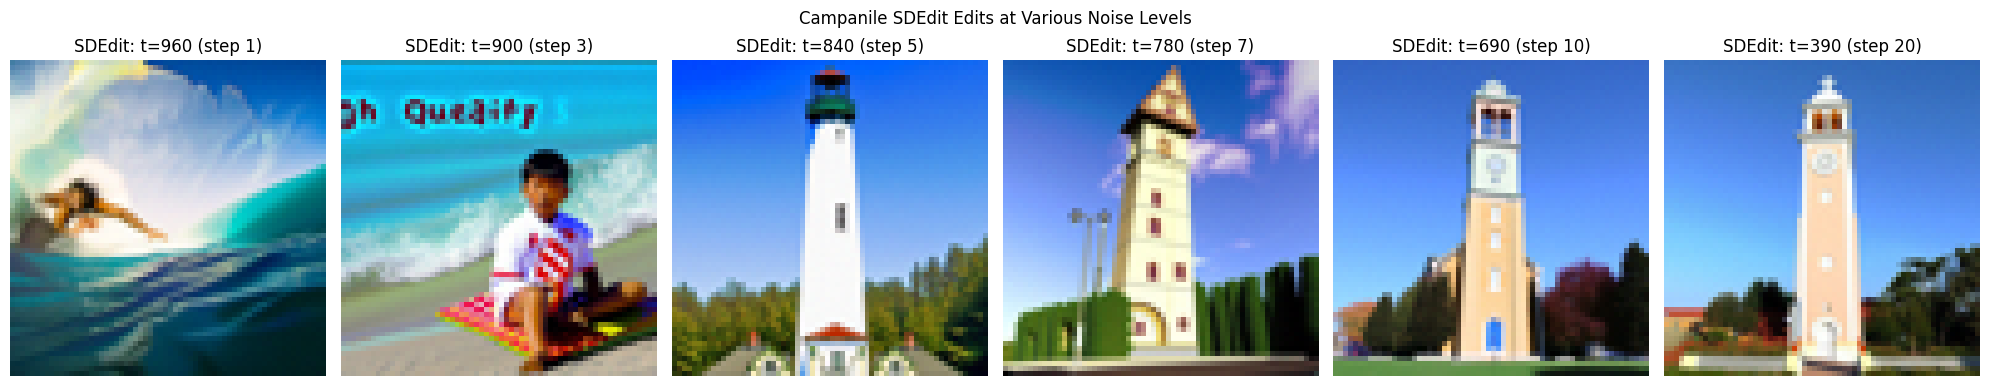

Could not load test_image1.jpg: [Errno 2] No such file or directory: 'test_image1.jpg'
Could not load test_image2.jpg: [Errno 2] No such file or directory: 'test_image2.jpg'


In [ ]:
# Edits of the Campanile image using SDEdit style editing

noisy_steps = [1, 3, 5, 7, 10, 20]
prompt = "a high quality photo"
cfg_scale = 7.5

# Load original Campanile image and preprocess it to [-1, 1] range, channels-first, float16 tensor
from PIL import Image
import torch

def load_and_preprocess_image(path, device):
    img = Image.open(path).convert("RGB").resize((64, 64))
    img = torch.from_numpy(np.array(img)).float() / 255.0       # [H, W, C], [0,1]
    img = img.permute(2, 0, 1)                                 # [C, H, W]
    img = img.unsqueeze(0)                                     # [1, C, H, W]
    img = img * 2.0 - 1.0                                      # [-1, 1]
    img = img.half().to(device)
    return img

campanile_image = load_and_preprocess_image('campanile.jpg', DEVICE)

sdedit_results = []
for steps in noisy_steps:
    # Generate noisy image by running the forward (diffusion) process to the given timestep
    current = campanile_image.clone()
    t = strided_timesteps[steps]
    # Forward process: add noise at time t
    noise = torch.randn_like(current)
    alpha_cumprod = stage_1.scheduler.alphas_cumprod[t].to(current.device)
    sqrt_alpha_cumprod = torch.sqrt(alpha_cumprod)
    sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alpha_cumprod)
    noisy_img = sqrt_alpha_cumprod * current + sqrt_one_minus_alpha_cumprod * noise
    noisy_img = noisy_img.squeeze(0)
    # Run iterative_denoise_cfg starting at step = steps, with CFG enabled and prompt
    # The function expects [C, H, W] shape (it adds batch internally)
    denoised_imgs = iterative_denoise_cfg(
        noisy_img,
        prompt,
        strided_timesteps,
        i_start=steps,
        cfg_scale=cfg_scale
    )
    result_img = denoised_imgs[-1]     # Get the final denoised image
    sdedit_results.append((steps, result_img))

# Plot all SDEdit results for Campanile
plt.figure(figsize=(20, 4))
for idx, (steps, img) in enumerate(sdedit_results):
    plt.subplot(1, len(noisy_steps), idx + 1)
    plt.imshow(to_pil_image(img))
    plt.axis("off")
    plt.title(f"SDEdit: t={strided_timesteps[steps].item()} (step {steps})")
plt.suptitle("Campanile SDEdit Edits at Various Noise Levels")
plt.tight_layout()
plt.show()


# Edits of two user-selected/test images using the same procedure

test_img_paths = ['test_image1.jpg', 'test_image2.jpg']  # REPLACE with your own images

for img_ix, img_path in enumerate(test_img_paths):
    try:
        input_img = load_and_preprocess_image(img_path, DEVICE)
    except Exception as e:
        print(f"Could not load {img_path}: {e}")
        continue
    results = []
    for steps in noisy_steps:
        t = strided_timesteps[steps]
        noise = torch.randn_like(input_img)
        alpha_cumprod = stage_1.scheduler.alphas_cumprod[t].to(input_img.device)
        sqrt_alpha_cumprod = torch.sqrt(alpha_cumprod)
        sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alpha_cumprod)
        noisy_img = sqrt_alpha_cumprod * input_img + sqrt_one_minus_alpha_cumprod * noise
        noisy_img = noisy_img.squeeze(0)
        denoised_imgs = iterative_denoise_cfg(
            noisy_img,
            prompt,
            strided_timesteps,
            i_start=steps,
            cfg_scale=cfg_scale
        )
        results.append((steps, denoised_imgs[-1]))
    plt.figure(figsize=(20, 4))
    for idx, (steps, img) in enumerate(results):
        plt.subplot(1, len(noisy_steps), idx + 1)
        plt.imshow(to_pil_image(img))
        plt.axis("off")
        plt.title(f"SDEdit: t={strided_timesteps[steps].item()} (step {steps})")
    plt.suptitle(f"Test Image {img_ix+1}: SDEdit Edits at Various Noise Levels")
    plt.tight_layout()
    plt.show()


In [ ]:
import os
from torchvision.transforms.functional import to_pil_image

output_dir_sdedit_campanile = "sdedit_campanile_results"
os.makedirs(output_dir_sdedit_campanile, exist_ok=True)

for idx, (steps, img) in enumerate(sdedit_results):
    # Using the 'steps' value from the sdedit_results tuple for the filename
    t_value = strided_timesteps[steps].item()
    filename = f"sdedit_campanile_t_{t_value}_step_{steps}.png"
    filepath = os.path.join(output_dir_sdedit_campanile, filename)
    to_pil_image(img).save(filepath)
    print(f"Saved SDEdit Campanile image (t={t_value}, step={steps}) to {filepath}")

Saved SDEdit Campanile image (t=960, step=1) to sdedit_campanile_results/sdedit_campanile_t_960_step_1.png
Saved SDEdit Campanile image (t=900, step=3) to sdedit_campanile_results/sdedit_campanile_t_900_step_3.png
Saved SDEdit Campanile image (t=840, step=5) to sdedit_campanile_results/sdedit_campanile_t_840_step_5.png
Saved SDEdit Campanile image (t=780, step=7) to sdedit_campanile_results/sdedit_campanile_t_780_step_7.png
Saved SDEdit Campanile image (t=690, step=10) to sdedit_campanile_results/sdedit_campanile_t_690_step_10.png
Saved SDEdit Campanile image (t=390, step=20) to sdedit_campanile_results/sdedit_campanile_t_390_step_20.png


### 1.7.1 Editing Hand-Drawn and Web Images


Saved s_edit_outputs/s_edit_porsche_sketch_t_960.png
Saved s_edit_outputs/s_edit_porsche_sketch_t_900.png
Saved s_edit_outputs/s_edit_porsche_sketch_t_840.png
Saved s_edit_outputs/s_edit_porsche_sketch_t_780.png
Saved s_edit_outputs/s_edit_porsche_sketch_t_690.png
Saved s_edit_outputs/s_edit_porsche_sketch_t_390.png


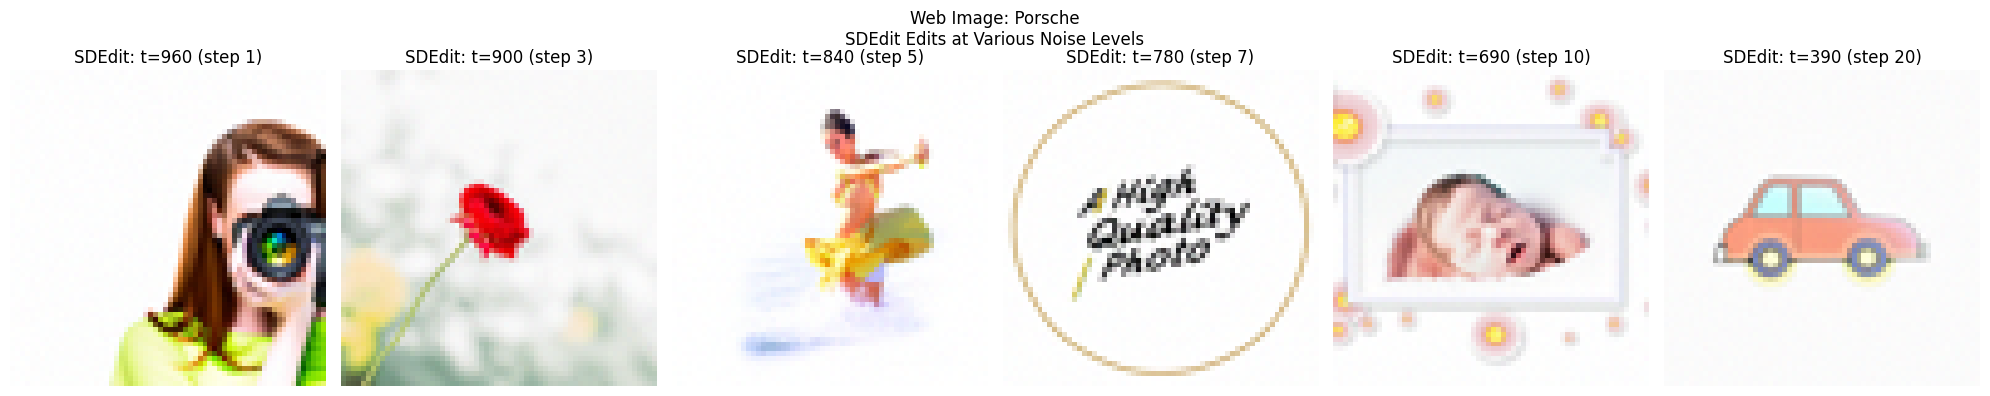

Saved s_edit_outputs/s_edit_football_sketch_t_960.png
Saved s_edit_outputs/s_edit_football_sketch_t_900.png
Saved s_edit_outputs/s_edit_football_sketch_t_840.png
Saved s_edit_outputs/s_edit_football_sketch_t_780.png
Saved s_edit_outputs/s_edit_football_sketch_t_690.png
Saved s_edit_outputs/s_edit_football_sketch_t_390.png


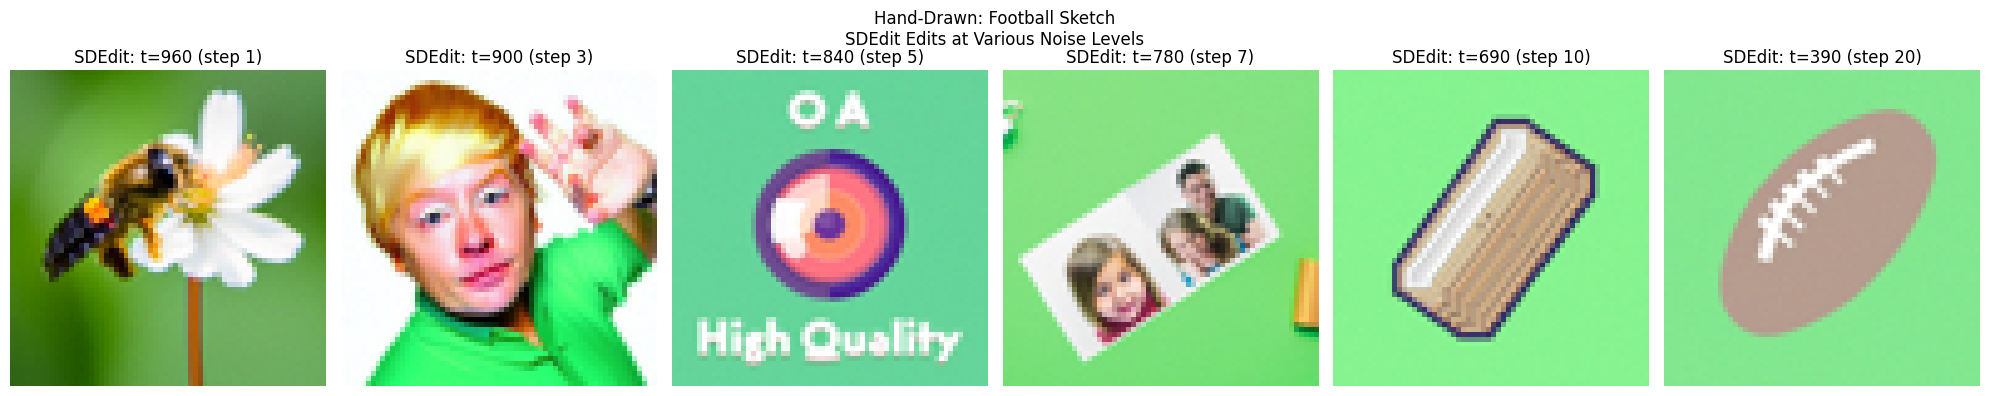

Saved s_edit_outputs/s_edit_golden_gate_sketch_t_960.png
Saved s_edit_outputs/s_edit_golden_gate_sketch_t_900.png
Saved s_edit_outputs/s_edit_golden_gate_sketch_t_840.png
Saved s_edit_outputs/s_edit_golden_gate_sketch_t_780.png
Saved s_edit_outputs/s_edit_golden_gate_sketch_t_690.png
Saved s_edit_outputs/s_edit_golden_gate_sketch_t_390.png


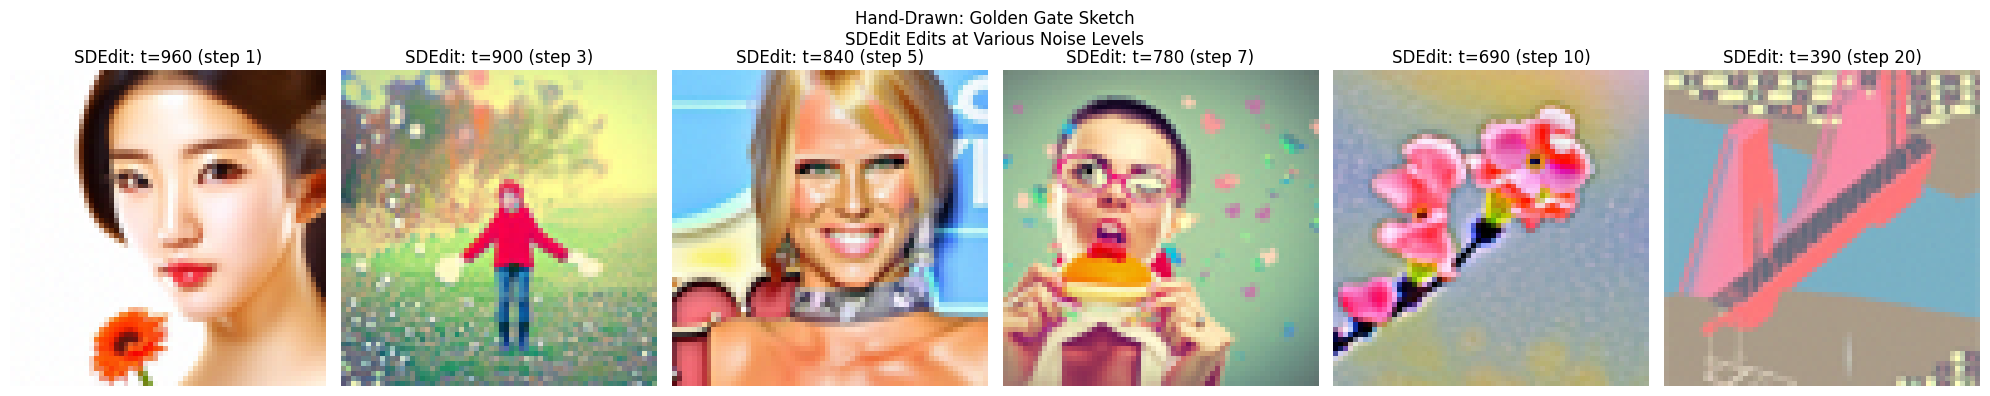

In [ ]:
import torchvision.transforms as transforms

import os
output_dir = "s_edit_outputs"
os.makedirs(output_dir, exist_ok=True)


web_img_path = "porsche_sketch.png"  # Internet image of your choice, e.g. Porsche car
hand_drawn_img_paths = ["football_sketch.png", "golden_gate_sketch.png"]  # Hand-drawn sketches
all_img_paths = [web_img_path] + hand_drawn_img_paths
img_titles = ["Web Image: Porsche", "Hand-Drawn: Football Sketch", "Hand-Drawn: Golden Gate Sketch"]

# Noise steps as specified
noisy_steps = [1, 3, 5, 7, 10, 20]
# If you wish, additional noise levels can be added here

for img_ix, (img_path, img_title) in enumerate(zip(all_img_paths, img_titles)):
    try:
        # Load and preprocess image, force resize to 64x64
        orig_img = Image.open(img_path).convert("RGB")
        orig_img = orig_img.resize((64, 64))
        orig_img = np.array(orig_img)
        # Preprocess for model (normalize, tensor, etc)
        input_img = torch.from_numpy(orig_img).half().to(DEVICE)
        if input_img.max() > 1.0:
            input_img = input_img / 255.0
        # Convert from (H, W, C) to (C, H, W) format
        input_img = input_img.permute(2, 0, 1)  # (64, 64, 3) -> (3, 64, 64)
    except Exception as e:
        print(f"Could not load {img_path}: {e}")
        continue

    results = []
    for steps in noisy_steps:
        t = strided_timesteps[steps]
        noise = torch.randn_like(input_img)
        alpha_cumprod = stage_1.scheduler.alphas_cumprod[t].to(input_img.device)
        sqrt_alpha_cumprod = torch.sqrt(alpha_cumprod)
        sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alpha_cumprod)
        noisy_img = sqrt_alpha_cumprod * input_img + sqrt_one_minus_alpha_cumprod * noise
        denoised_imgs = iterative_denoise_cfg(
            noisy_img,
            prompt,
            strided_timesteps,
            i_start=steps,
            cfg_scale=cfg_scale
        )
        results.append((steps, denoised_imgs[-1]))



    plt.figure(figsize=(20, 4))
    for idx, (steps, img) in enumerate(results):
        out_img = to_pil_image(img)
        img_base = os.path.splitext(os.path.basename(img_path))[0]
        save_name = f"s_edit_{img_base}_t_{strided_timesteps[steps].item()}.png"
        save_path = os.path.join(output_dir, save_name)
        out_img.save(save_path)
        print(f"Saved {save_path}")
        plt.subplot(1, len(noisy_steps), idx + 1)
        plt.imshow(to_pil_image(img))
        plt.axis("off")
        plt.title(f"SDEdit: t={strided_timesteps[steps].item()} (step {steps})")
    plt.suptitle(f"{img_title}\nSDEdit Edits at Various Noise Levels")
    plt.tight_layout()
    plt.show()



### 1.7.2 Inpainting


In [ ]:
import torch

def inpaint(
    image,
    mask,
    prompt_key,
    timesteps,
    i_start,
    cfg_scale=7.5
):
    """
    Inpainting loop using Classifier-Free Guidance (CFG).

    Args:
        image: The initial image (tensor 64x64).
        mask: The mask used for deciding where to put new content (tensor 64x64).
        prompt_key: Key for the prompt in prompt_dict (string).
        timesteps: List or array of timesteps.
        i_start: Starting timestep index.
        cfg_scale: Guidance scale (float).

    Returns:
        A list of image tensors for each denoising step.
    """
    im_current = forward(image, timesteps[i_start])
    im_current = image.clone().to(stage_1.unet.device).to(stage_1.unet.dtype)
    im_current = im_current.unsqueeze(0)  # Add batch dimension: (1, C, H, W)
    all_images = []

    # Get conditional and unconditional embeddings from prompt_dict
    cond_emb = prompt_dict[prompt_key].to(stage_1.unet.device).to(stage_1.unet.dtype)
    uncond_emb = prompt_dict[''].to(stage_1.unet.device).to(stage_1.unet.dtype)

    with torch.no_grad():
        for i in range(i_start, len(timesteps) - 1):

            t = timesteps[i]  # Current timestep (more noisy)
            t_prime = timesteps[i + 1]  # Next timestep (less noisy)

            # Get alpha_bar_t
            alpha_bar_t = alphas_cumprod[t].to(stage_1.unet.device)
            alpha_bar_t = alpha_bar_t.view(1, 1, 1, 1).type_as(im_current)

            # Get alpha_bar_t_prime
            alpha_bar_t_prime = alphas_cumprod[t_prime].to(stage_1.unet.device)
            alpha_bar_t_prime = alpha_bar_t_prime.view(1, 1, 1, 1).type_as(im_current)

            # alpha_t
            alpha_t = alpha_bar_t / alpha_bar_t_prime
            beta_t = 1.0 - alpha_t

            # Prepare timestep tensor
            t_tensor = torch.tensor([t], device=stage_1.unet.device, dtype=torch.long)

            # UNet forward (unconditional)
            model_output_uncond, = stage_1.unet(
                im_current,
                t_tensor,
                encoder_hidden_states=uncond_emb,
                return_dict=False,
            )
            eps_pred_uncond = model_output_uncond[:, :3, :, :]  # (1, 3, 64, 64)
            pred_var_uncond = model_output_uncond[:, 3:, :, :]

            # UNet forward (conditional)
            model_output_cond, = stage_1.unet(
                im_current,
                t_tensor,
                encoder_hidden_states=cond_emb,
                return_dict=False,
            )
            eps_pred_cond = model_output_cond[:, :3, :, :]  # (1, 3, 64, 64)
            pred_var_cond = model_output_cond[:, 3:, :, :]

            # CFG mixing
            guided_eps_pred = eps_pred_uncond + cfg_scale * (eps_pred_cond - eps_pred_uncond)
            guided_var = pred_var_uncond + cfg_scale * (pred_var_cond - pred_var_uncond)
            # Use conditional variance
            pred_var = pred_var_cond

            sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
            sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)

            # One step denoising
            x0_hat = (im_current - sqrt_one_minus_alpha_bar_t * guided_eps_pred) / sqrt_alpha_bar_t

            # Formula 3
            x_prev = (torch.sqrt(alpha_bar_t_prime) * beta_t) / (1 - alpha_bar_t) * x0_hat + (torch.sqrt(alpha_t)*(1- alpha_bar_t_prime)) / (1 - alpha_bar_t) * im_current

            # Add variance
            im_current = add_variance(guided_var, t, x_prev)


            im_noisy_at_timestep = forward(image, t)
            im_current = im_current * mask + im_noisy_at_timestep * (1 - mask)


            all_images.append(im_current.squeeze(0).detach().cpu().clamp(0.0, 1.0))


    # Final image (convert back to [0, 1])
    final_image = im_current * mask + orig_img
    final_image = final_image.squeeze(0).detach().cpu().clamp(0.0, 1.0)
    all_images.append(final_image)

    return all_images

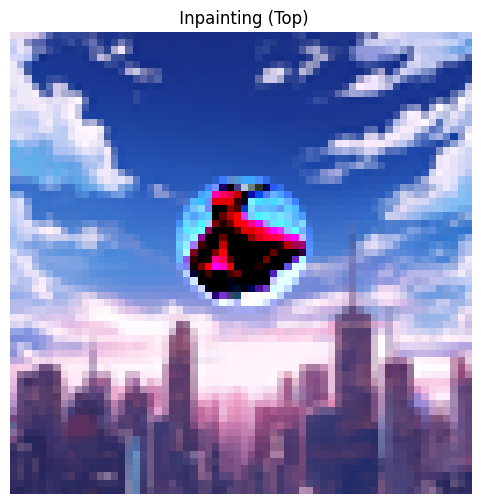

In [ ]:
import numpy as np
import torch
from PIL import Image
from torchvision.transforms.functional import to_pil_image


# Load the original Campanile image (resize to 64x64 just in case)
orig_img = Image.open("skyline.jpg")
mask = Image.open("lens_mask.jpg")

orig_img = orig_img.resize((64, 64))
mask = mask.resize((64, 64))

orig_img = torch.from_numpy(np.array(orig_img)).half().to(DEVICE).permute(2, 0, 1) / 255
# Convert mask to grayscale (single channel)
mask_np = np.array(mask.convert("L"))  # "L" mode = grayscale
# Normalize to [0,1]: 0 if black, 1 if white
mask = torch.from_numpy(mask_np).half().to(DEVICE).unsqueeze(0) / 255


prompt_key = "a high quality photo"
i_start = 0
cfg_scale = 7.5

inpainted_pic = inpaint(orig_img, mask, prompt_key, strided_timesteps, i_start, cfg_scale)



# Show/save the inpainted result
inpainted_img = to_pil_image(inpainted_pic[-1])
# inpainted_img.save("inpainting_outputs/campanile_top_inpainted.png")
plt.figure(figsize=(6, 6))
plt.imshow(inpainted_img)
plt.title(" Inpainting (Top)")
plt.axis("off")
plt.show()


In [ ]:
inpainted_img.save("skyline_inpainted.png")

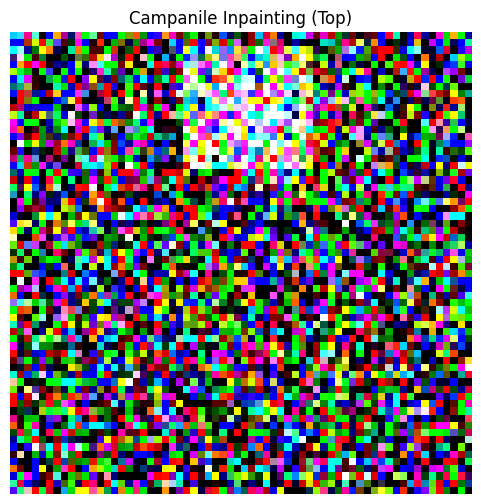

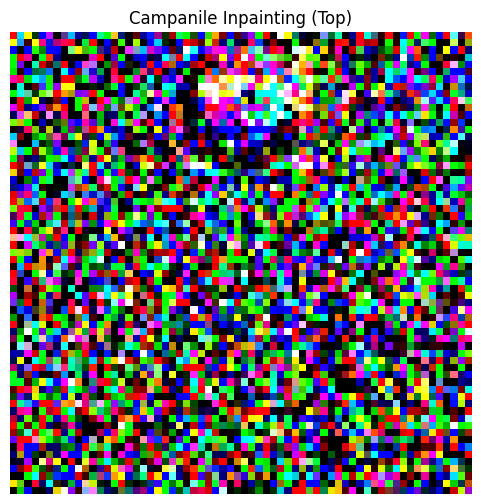

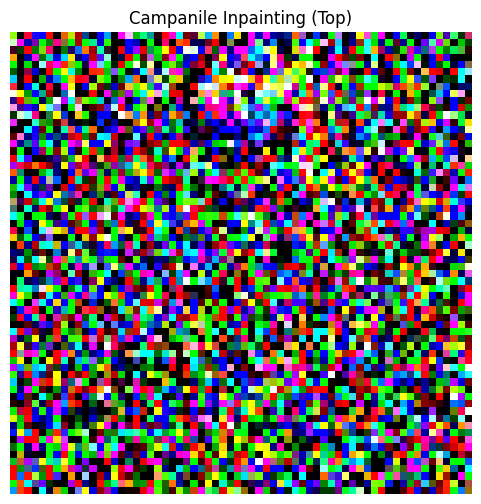

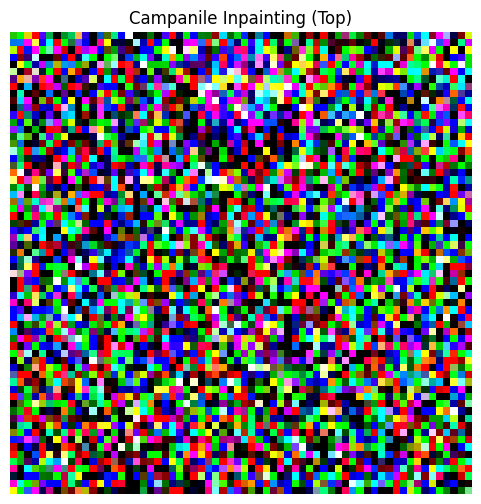

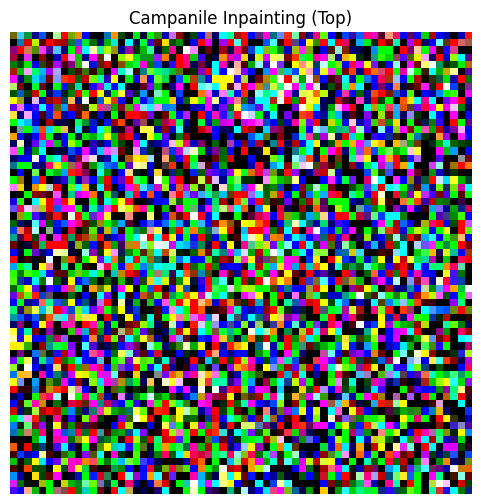

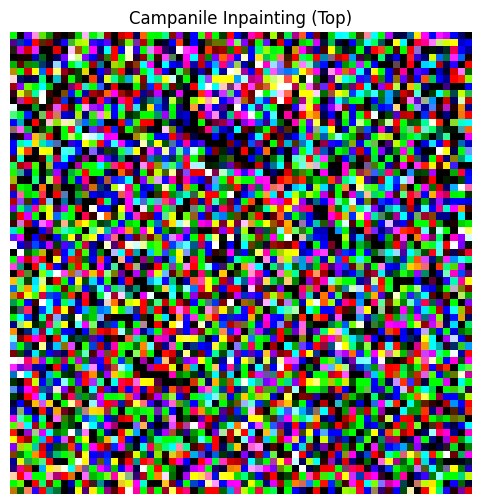

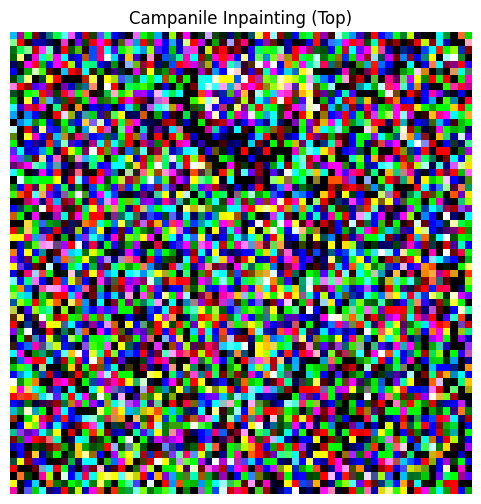

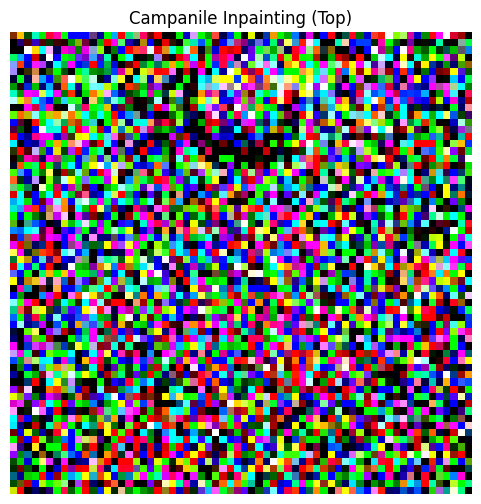

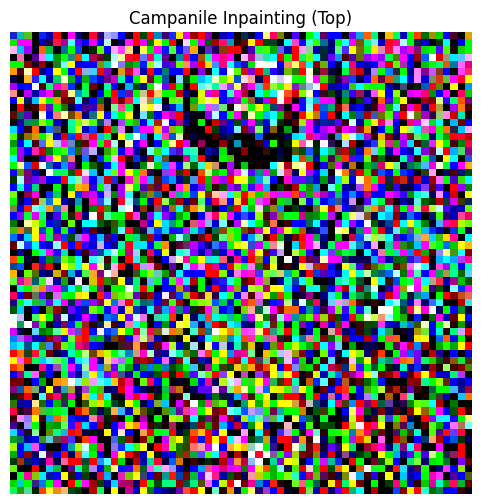

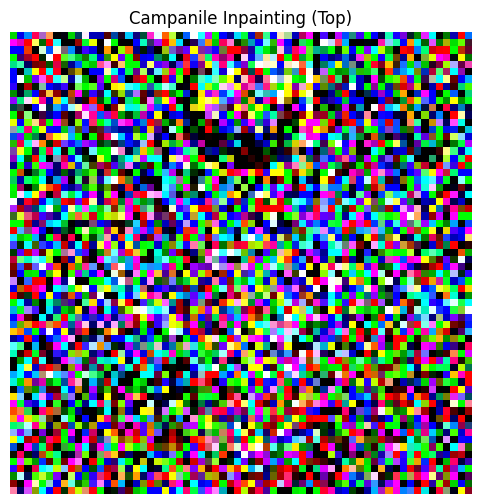

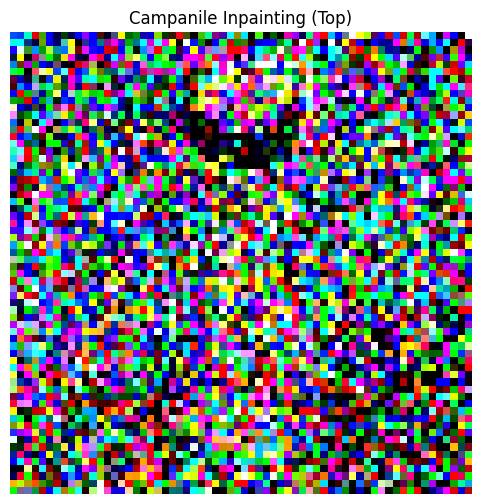

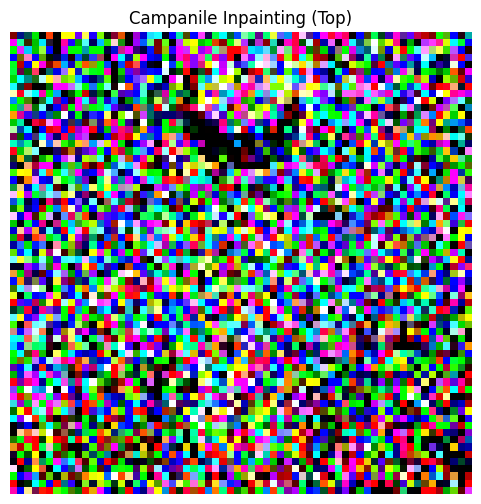

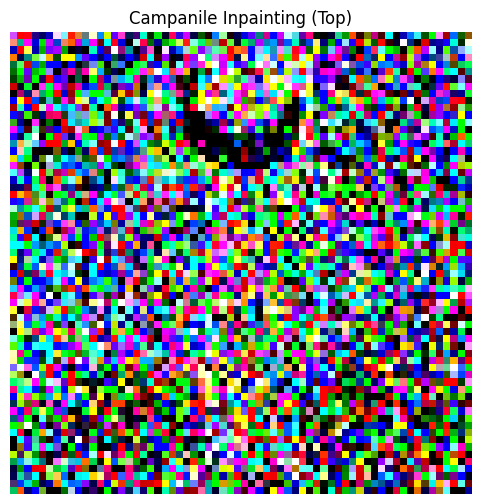

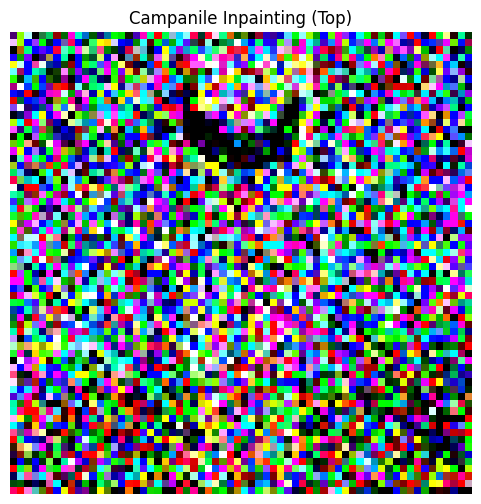

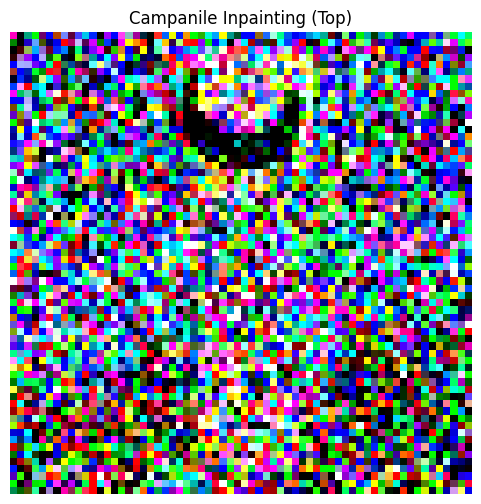

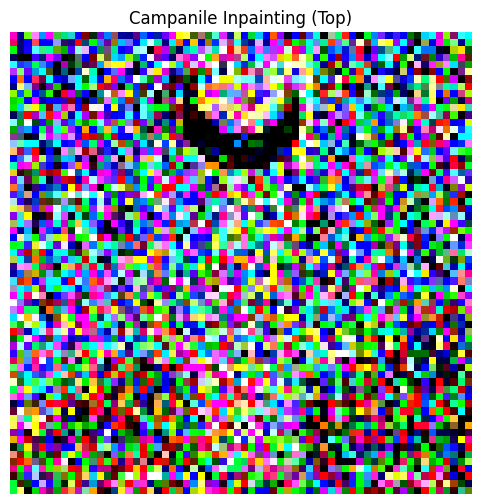

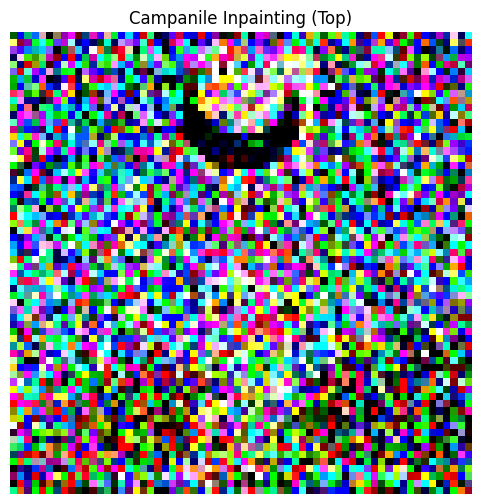

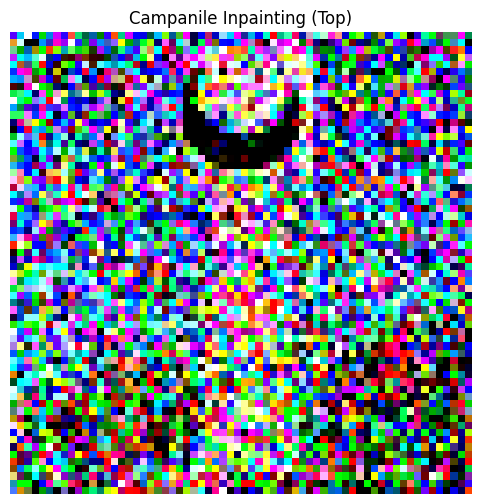

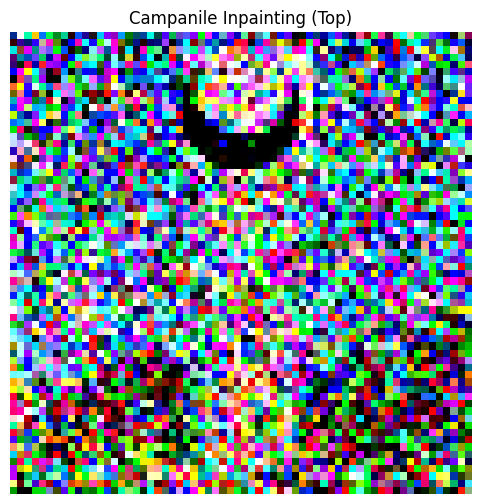

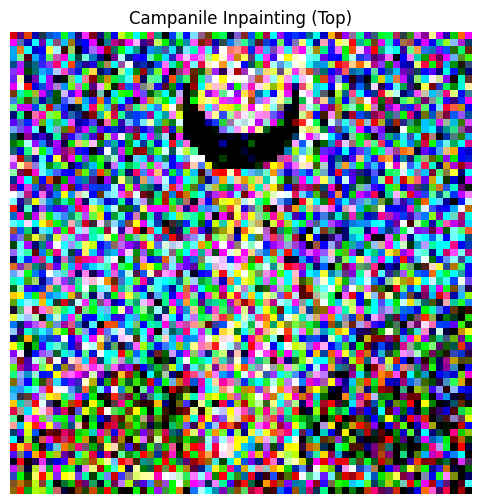

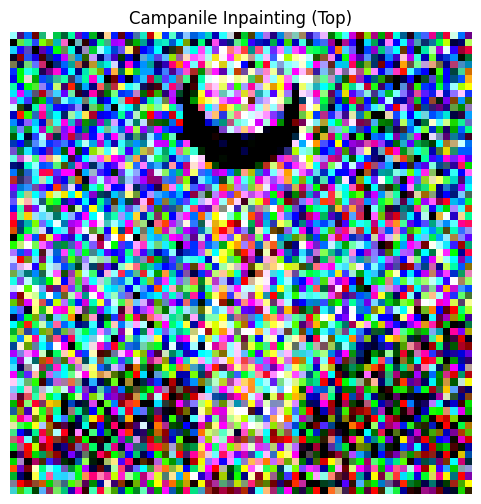

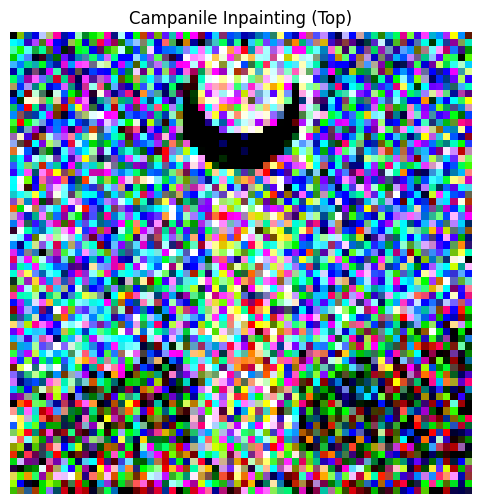

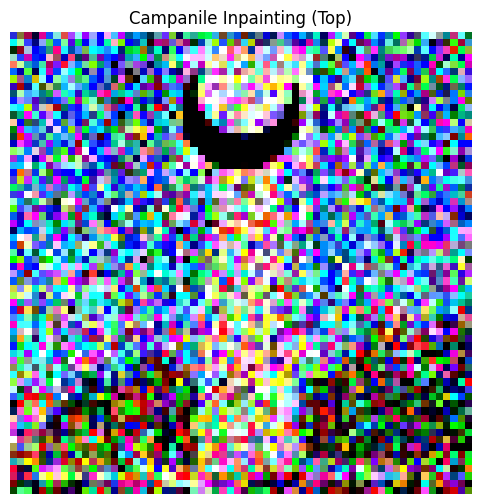

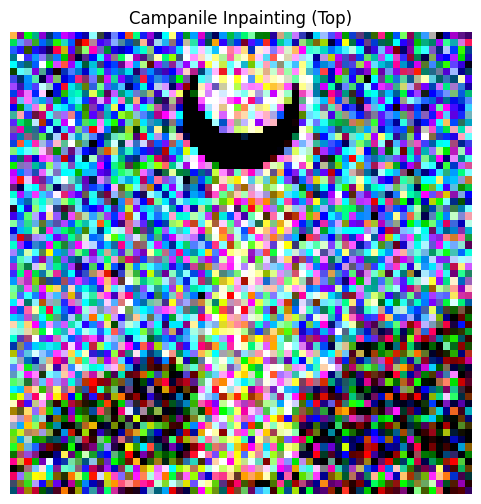

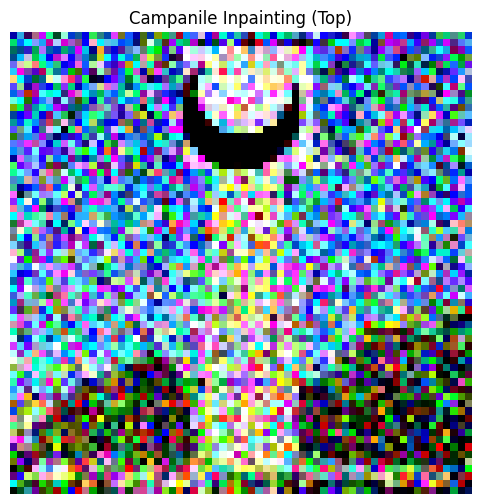

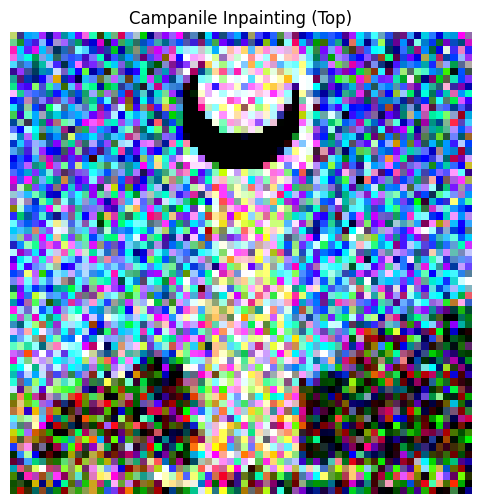

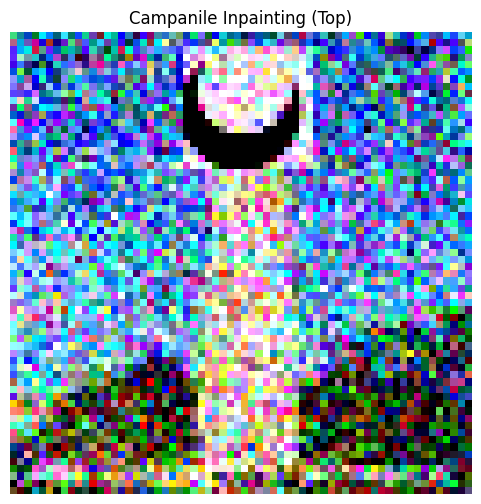

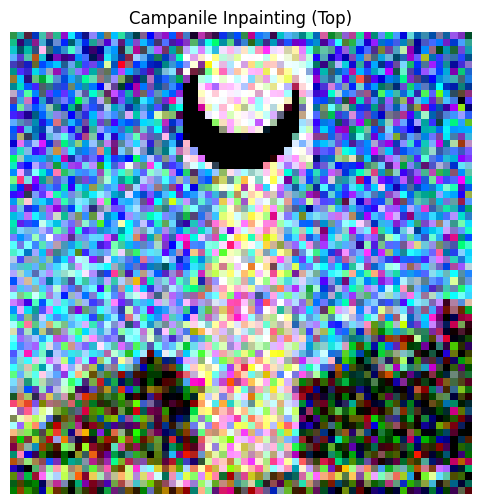

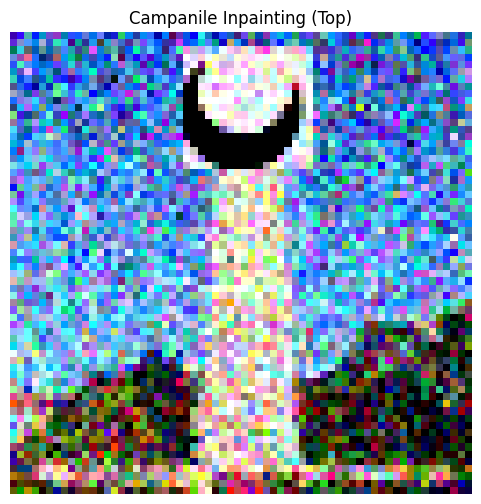

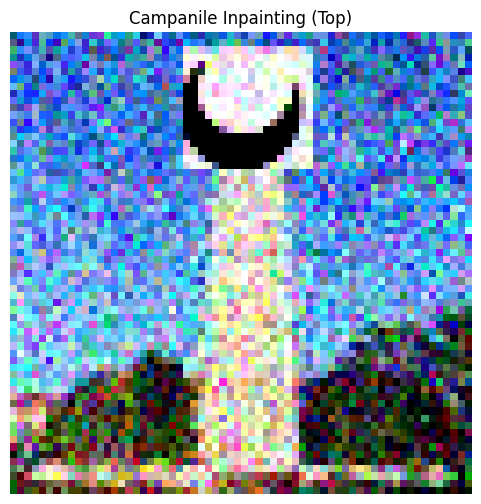

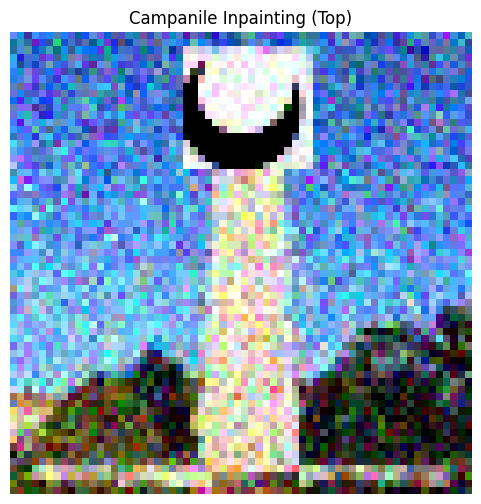

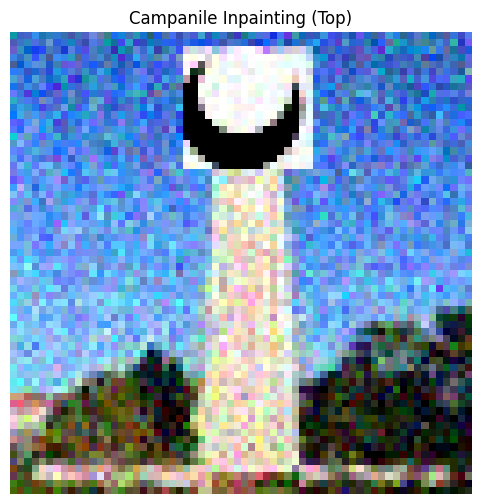

In [ ]:
for i in range(32):
  inpainted_img = to_pil_image(inpainted_pic[i])
  # inpainted_img.save("inpainting_outputs/campanile_top_inpainted.png")
  plt.figure(figsize=(6, 6))
  plt.imshow(inpainted_img)
  plt.title("Campanile Inpainting (Top)")
  plt.axis("off")
  plt.show()

### 1.7.3 Text conditional Image-to-image Translation

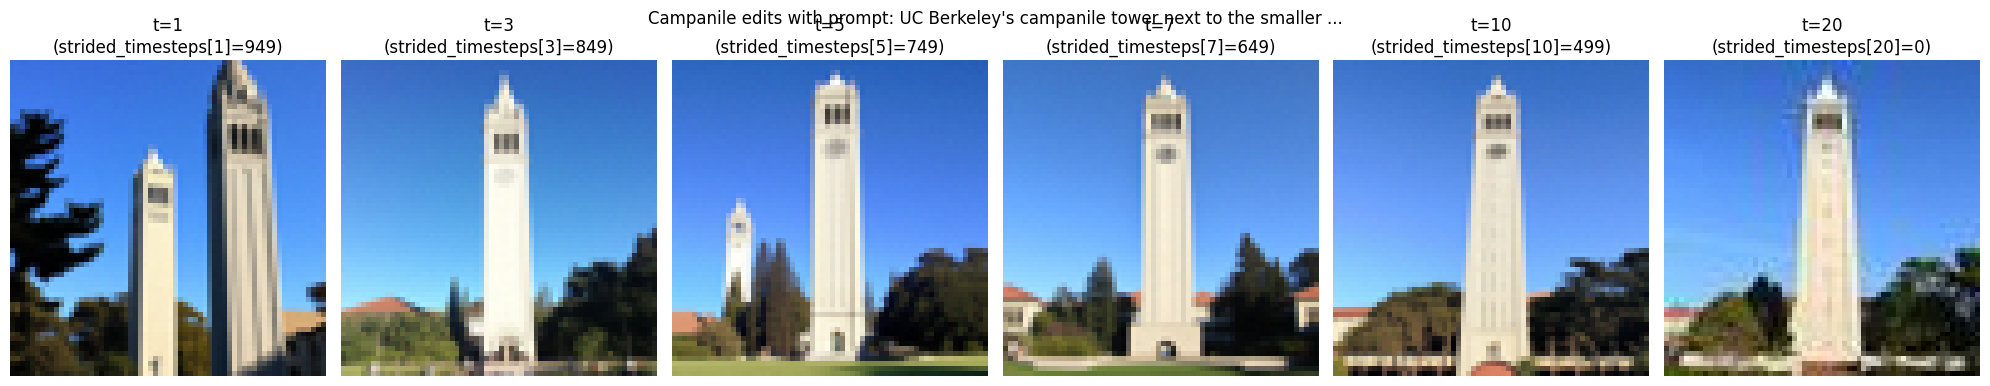

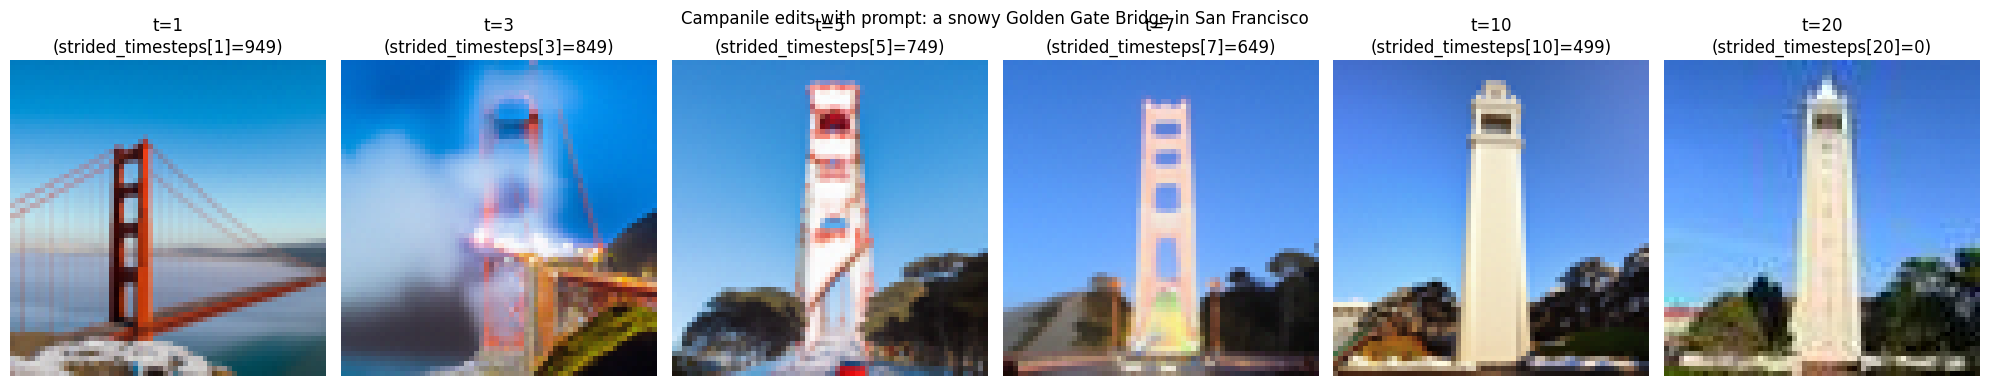

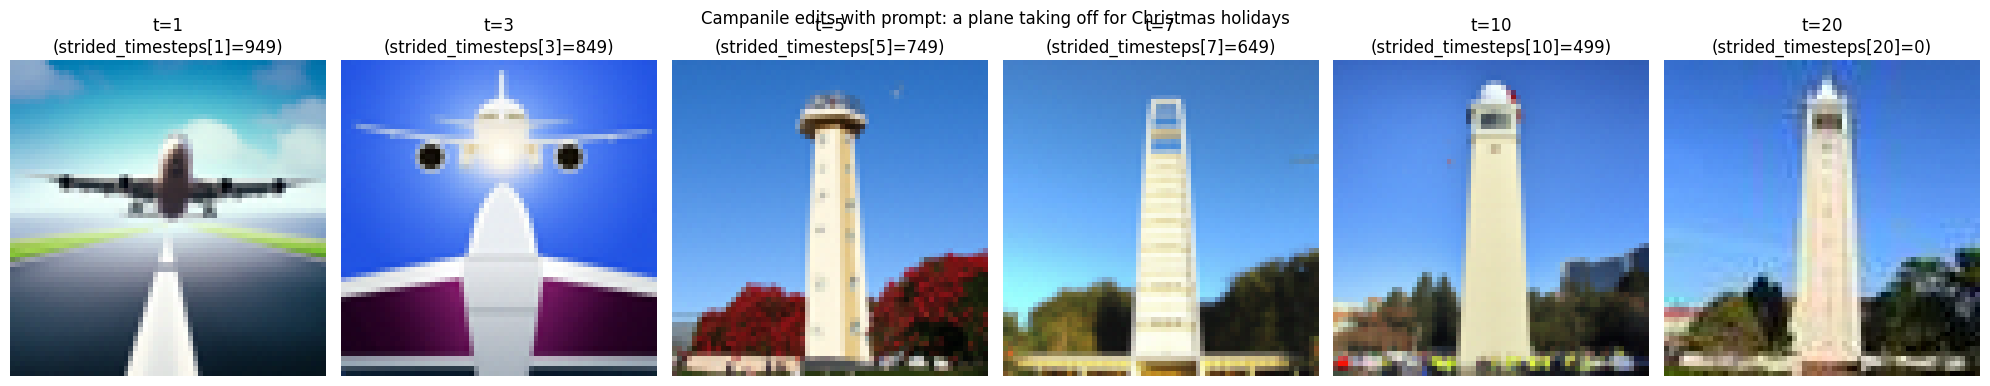

In [ ]:
from typing import Any


import matplotlib.pyplot as plt

# 1.7.3 Text-Conditional Image-to-image Translation

# Edits of the Campanile at various noise levels with creative prompts
# Use prompts from prompt_dict (excluding empty string)
campanile_prompts = [
 "UC Berkeley's campanile tower next to the smaller Hoover tower",
 "a snowy Golden Gate Bridge in San Francisco",
 "a plane taking off for Christmas holidays"

]
edit_timesteps = [1, 3, 5, 7, 10, 20]

campanile_img = np.asarray(Image.open("campanile.jpg").resize((64, 64))).astype(np.float32) / 255.0
campanile_img = torch.from_numpy(campanile_img).permute(2, 0, 1).to(DEVICE)
# Convert to [-1, 1] range for iterative_denoise_cfg
campanile_img = campanile_img * 2.0 - 1.0

# Generate images for each prompt at all timesteps
for prompt in campanile_prompts:
    results = []
    for i_start in edit_timesteps:
        # Add noise at timestep strided_timesteps[i_start]
        t = strided_timesteps[i_start]
        noise = torch.randn_like(campanile_img)
        alpha_cumprod = stage_1.scheduler.alphas_cumprod[t].to(campanile_img.device)
        sqrt_alpha_cumprod = torch.sqrt(alpha_cumprod)
        sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alpha_cumprod)
        noisy_img = sqrt_alpha_cumprod * campanile_img + sqrt_one_minus_alpha_cumprod * noise

        # Run iterative_denoise_cfg
        denoised_imgs = iterative_denoise_cfg(
            noisy_img,
            prompt,
            strided_timesteps,
            i_start=i_start,
            cfg_scale=3.5
        )
        results.append((i_start, denoised_imgs[-1]))

    # Plot all timesteps for this prompt and save images
    plt.figure(figsize=(20, 4))
    for idx, (i_start, img) in enumerate(results):
        plt.subplot(1, len(edit_timesteps), idx + 1)
        img_pil = to_pil_image(img)
        plt.imshow(img_pil)
        plt.title(f"t={i_start}\n(strided_timesteps[{i_start}]={strided_timesteps[i_start].item()})")
        plt.axis("off")
        # Save each individual image
        # Create a safe filename for the prompt (first 30 chars, replace spaces with underscores)
        prompt_part = prompt[:30].replace(" ", "_").replace("/", "_")
        img_save_path = f"creative_edits/campanile_edit_{prompt_part}_t{i_start}_stride{strided_timesteps[i_start].item()}.png"
        # Make directory if it doesn't exist
        import os
        os.makedirs(os.path.dirname(img_save_path), exist_ok=True)
        img_pil.save(img_save_path)

    plt.suptitle(f"Campanile edits with prompt: {prompt[:50]}{'...' if len(prompt) > 50 else ''}")
    plt.tight_layout()
    # Save the whole figure, as well
    fig_save_path = f"creative_edits/row_{prompt[:30].replace(' ','_').replace('/', '_')}.png"
    plt.savefig(fig_save_path)
    plt.show()



## 1.8 Visual anagrams

In [ ]:
anagram_path = "prompt_embeds_dict_anagrams.pth"

anagram_prompts = torch.load(anagram_path, map_location=DEVICE)
print("Loaded prompts:")
for k in anagram_prompts.keys():
    print(" -", k)

Loaded prompts:
 - an oil painting of a bear
 - an oil painting of a duck
 - a painting of  a wine glass
 - a painting of a candle
 - a pencil sketch of a car
 - a pencil sketch of a bathing tub
 - 


Visual anagram: 'an oil painting of a bear' <-> 'an oil painting of a duck'
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybird.shape torch.Size([1, 6, 64, 64])
t.shape torch.Size([])
x_t.shape torch.Size([1, 3, 64, 64])
e_hybi

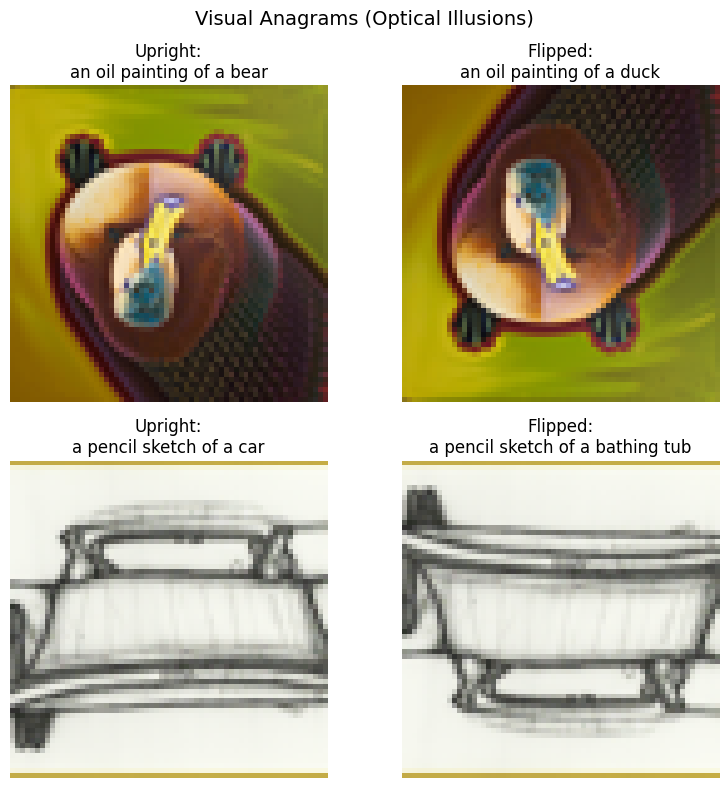

In [ ]:
import torch
import torch.nn.functional as F
from torchvision.transforms.functional import vflip, to_pil_image
import matplotlib.pyplot as plt

def visual_anagrams(
    prompt_embed_1,
    prompt_embed_2,
    unet,                  # Diffusion denoising unet
    scheduler,             # Scheduler for sampling/steps
    num_inference_steps=50,
    guidance_scale=7.5,
    seed=13,
    img_size=64,
    device="cuda"
):
    torch.manual_seed(seed)
    # Start from random noise
    x_t = torch.randn(1, 3, img_size, img_size, device=device)

    # Need an array of timesteps as per scheduler
    scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = scheduler.timesteps

    with torch.no_grad():
        for i, t in enumerate(timesteps):
            # Classifier-free guidance as in Stable Diffusion
            # (duplicated batch: [cond, uncond])
            x_in = torch.cat([x_t] * 2)
            t_in = torch.stack([t] * 2)
            # Prompts for both anagrams
            # First, p1/cond, then uncond (zeros)
            # UNet input expects [uncond_embed, cond_embed]
            cond_embed_1 = prompt_embed_1
            cond_embed_2 = prompt_embed_2
            # Handles both batch and singleton
            if cond_embed_1.ndim == 2:
                cond_embed_1 = cond_embed_1.unsqueeze(0)
            if cond_embed_2.ndim == 2:
                cond_embed_2 = cond_embed_2.unsqueeze(0)
            uncond_embed = prompt_dict[""]
            prompt_embeds_1 = torch.cat([uncond_embed, cond_embed_1])
            prompt_embeds_2 = torch.cat([uncond_embed, cond_embed_2])

            # ε1
            eps1 = unet(x_in.half(), t_in.half(), encoder_hidden_states=prompt_embeds_1.half()).sample


            # Flip x_t upside down, UNet expects [uncond, cond] as batch
            flipped_x_t = vflip(x_t)
            flipped_x_in = torch.cat([flipped_x_t] * 2)
            eps2 = unet(flipped_x_in.half(), t_in.half(), encoder_hidden_states=prompt_embeds_2.half()).sample
            # Unflip the output
            eps2 = vflip(eps2)

            # Classifier-free guidance for both: eps = uncond + scale * (cond - uncond)
            eps1_guided = eps1[0] + guidance_scale * (eps1[1] - eps1[0])
            eps2_guided = eps2[0] + guidance_scale * (eps2[1] - eps2[0])

            # Average the two noise estimates
            eps = (eps1_guided + eps2_guided) / 2

            # Denoising step
            eps = eps.unsqueeze(0)
            print("e_hybird.shape", eps.shape)
            print("t.shape", t.shape)
            print("x_t.shape", x_t.shape)
            x_t = scheduler.step(eps, t, x_t).prev_sample

    # Output the final denoised image
    image = x_t.clamp(-1, 1) * 0.5 + 0.5  # range to [0,1]
    image = image.cpu().squeeze()
    return image

# -- EXAMPLES --

# Pick two pairs of anagram-style prompts from the loaded dict:
anagram_pairs = [
    ("an oil painting of a bear", "an oil painting of a duck"),
    # Second illusion prompt of your choice:
    ("a pencil sketch of a car", "a pencil sketch of a bathing tub"),
]

fig, axs = plt.subplots(len(anagram_pairs), 2, figsize=(8, 8))
for row_idx, (p1, p2) in enumerate(anagram_pairs):
    print(f"Visual anagram: '{p1}' <-> '{p2}'")
    # Get prompt embeddings from dict
    emb1 = anagram_prompts[p1]
    emb2 = anagram_prompts[p2]
    output = visual_anagrams(
        emb1, emb2,
        stage_1.unet, scheduler=stage_1.scheduler
    )

    # Show original
    axs[row_idx, 0].imshow(to_pil_image(output))
    axs[row_idx, 0].set_title(f"Upright:\n{p1}")
    axs[row_idx, 0].axis("off")
    # Show flipped
    flipped_output = vflip(output)
    axs[row_idx, 1].imshow(to_pil_image(flipped_output))
    axs[row_idx, 1].set_title(f"Flipped:\n{p2}")
    axs[row_idx, 1].axis("off")
    # Optionally, save images
    save_dir = "visual_anagrams"
    import os
    os.makedirs(save_dir, exist_ok=True)
    to_pil_image(output).save(os.path.join(save_dir, f"anagram_{row_idx}_upright.png"))
    to_pil_image(flipped_output).save(os.path.join(save_dir, f"anagram_{row_idx}_flipped.png"))

plt.suptitle("Visual Anagrams (Optical Illusions)", fontsize=14)
plt.tight_layout()
plt.show()




## Hybrid images

Generating hybrid images...
  Generating hybrid image with cutoff=2...
  Generating hybrid image with cutoff=4...
  Generating hybrid image with cutoff=8...
  Generating hybrid image with cutoff=16...


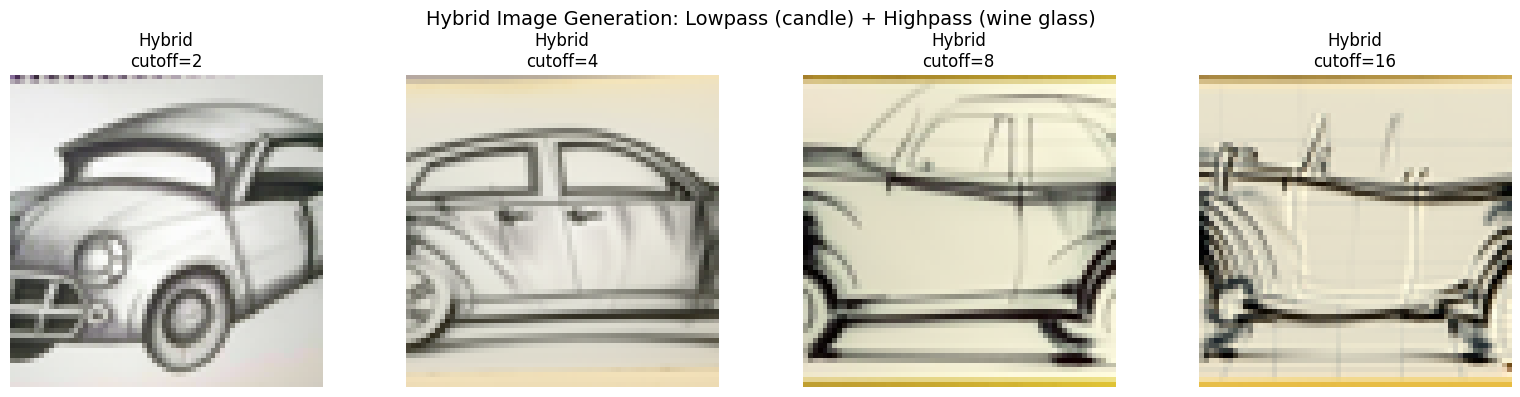

In [ ]:
p_embed_1 = anagram_prompts['a pencil sketch of a bathing tub']
p_embed_2 = anagram_prompts['a pencil sketch of a car']

def lowpass(img, cutoff=8):
    """
    Apply a lowpass filter to the image using FFT.
    img: torch.Tensor of shape (C,H,W)
    cutoff: lower values allow fewer frequencies (in pixels)
    """
    import torch
    # FFT
    img_fft = torch.fft.fft2(img)
    img_fft_shift = torch.fft.fftshift(img_fft)
    C, H, W = img.shape

    # Create lowpass mask
    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
    center_y, center_x = H // 2, W // 2
    mask = ((yy - center_y)**2 + (xx - center_x)**2) < cutoff**2
    mask = mask.to(img.device)
    mask = mask.unsqueeze(0).repeat(C, 1, 1)

    # Apply mask
    img_fft_shift = img_fft_shift * mask

    # Inverse FFT
    img_fft = torch.fft.ifftshift(img_fft_shift)
    img_low = torch.fft.ifft2(img_fft).real
    return img_low

def highpass(img, cutoff=8):
    """
    Apply a highpass filter to the image using FFT.
    img: torch.Tensor of shape (C,H,W)
    cutoff: lower values allow fewer frequencies (in pixels)
    """
    import torch
    # FFT
    img_fft = torch.fft.fft2(img)
    img_fft_shift = torch.fft.fftshift(img_fft)
    C, H, W = img.shape

    # Create highpass mask
    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
    center_y, center_x = H // 2, W // 2
    mask = ((yy - center_y)**2 + (xx - center_x)**2) >= cutoff**2
    mask = mask.to(img.device)
    mask = mask.unsqueeze(0).repeat(C, 1, 1)

    # Apply mask
    img_fft_shift = img_fft_shift * mask

    # Inverse FFT
    img_fft = torch.fft.ifftshift(img_fft_shift)
    img_high = torch.fft.ifft2(img_fft).real
    return img_high

def get_noise_estimate(unet, x_t, t, prompt_emb, guidance_scale=7.5):
    # Assume classifier-free guidance
    # unet(x_t, t, encoder_hidden_states) returns e
    # For classifier-free guidance, input two encodings (with and without prompt), then do blending
    e_uncond = unet(x_t.half(), t.half(), encoder_hidden_states=prompt_dict[''].half()).sample
    e_cond = unet(x_t.half(), t.half(), encoder_hidden_states=prompt_emb.half()).sample
    e = e_uncond + guidance_scale * (e_cond - e_uncond)
    return e

# Hybridize noise estimates for two prompts and visualize
import torch
from torchvision.transforms.functional import to_pil_image

def hybrid_noise_estimate(unet, x_t, t, prompt_emb1, prompt_emb2, cutoff, guidance_scale):
    e1 = get_noise_estimate(unet, x_t, t, prompt_emb1, guidance_scale)
    e2 = get_noise_estimate(unet, x_t, t, prompt_emb2, guidance_scale)
    e1_pred = e1[:, :3, :, :].squeeze(0)
    e2_pred = e2[:, :3, :, :].squeeze(0)
    e1_var = e1[:, 3:, :, :].squeeze(0)
    e2_var = e2[:, 3:, :, :].squeeze(0)
    e1_low = lowpass(e1_pred, cutoff)
    e2_high = highpass(e2_pred, cutoff)
    e1_low_var = lowpass(e1_var, cutoff)
    e2_high_var = highpass(e2_var, cutoff)
    e1_low = torch.cat((e1_low, e1_low_var))
    e2_high = torch.cat((e2_high, e2_high_var))
    e_hybrid = e1_low + e2_high
    return e1, e2, e_hybrid

# Add noise at timestep t
timestep = torch.tensor([250], device=DEVICE)
scheduler = stage_1.scheduler
SNR = 1.0
img_noisy = torch.randn(1, 3, 64, 64, device=DEVICE)

# Function to generate final images using hybrid noise estimates
def generate_hybrid_image(unet, scheduler, prompt_emb1, prompt_emb2, cutoff=3,
                          guidance_scale=7.5, num_inference_steps=50,
                          img_size=64, device=DEVICE, seed=SEED):
    """
    Generate an image using hybrid noise estimates (lowpass from prompt1, highpass from prompt2).
    """
    torch.manual_seed(seed)

    # Start from random noise
    x_t = torch.randn(1, 3, img_size, img_size, device=device)

    # Set up scheduler timesteps
    scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = scheduler.timesteps

    with torch.no_grad():
        for i, t in enumerate(timesteps):
            # Get hybrid noise estimate at this timestep
            e1, e2, e_hybrid = hybrid_noise_estimate(unet, x_t, t, prompt_emb1, prompt_emb2,
                                                      cutoff, guidance_scale)

            # e_hybrid is (C, H, W), need to add batch dimension and ensure correct shape
            e_hybrid = e_hybrid.unsqueeze(0)  # (1, C, H, W)

            # Denoising step
            x_t = scheduler.step(e_hybrid, t, x_t).prev_sample

    # Convert to [0, 1] range
    image = x_t.clamp(-1, 1) * 0.5 + 0.5
    image = image.cpu().squeeze(0)  # Remove batch dimension
    return image


# Generate hybrid images with different cutoffs
cutoffs_to_test = [2, 4, 8, 16]

print("Generating hybrid images...")
hybrid_results = []
for cutoff in cutoffs_to_test:
    print(f"  Generating hybrid image with cutoff={cutoff}...")
    img = generate_hybrid_image(
        stage_1.unet,
        stage_1.scheduler,
        p_embed_1,
        p_embed_2,
        cutoff=cutoff,
        guidance_scale=7.5,
        num_inference_steps=50,
        img_size=64,
        device=DEVICE,
        seed=SEED
    )
    hybrid_results.append({"cutoff": cutoff, "image": img})


# Visualize hybrid images
fig, axs = plt.subplots(1, len(cutoffs_to_test), figsize=(4 * (len(cutoffs_to_test)), 4))


# Show hybrid images
for idx, result in enumerate(hybrid_results):
    axs[idx].imshow(to_pil_image(result["image"]))
    axs[idx].set_title(f"Hybrid\ncutoff={result['cutoff']}")
    axs[idx].axis("off")

plt.suptitle("Hybrid Image Generation: Lowpass (candle) + Highpass (wine glass)", fontsize=14)
plt.tight_layout()
plt.show()




In [ ]:
import os
from torchvision.transforms.functional import to_pil_image

output_dir_hybrid = "hybrid_car"
os.makedirs(output_dir_hybrid, exist_ok=True)

for i, res in enumerate(hybrid_results):
    cutoff_value = res["cutoff"]
    img_to_save = res["image"]
    filename = f"hybrid_car_cutoff_{cutoff_value}.png"
    filepath = os.path.join(output_dir_hybrid, filename)
    to_pil_image(img_to_save).save(filepath)
    print(f"Saved hybrid image (cutoff={cutoff_value}) to {filepath}")

Saved hybrid image (cutoff=2) to hybrid_car/hybrid_car_cutoff_2.png
Saved hybrid image (cutoff=4) to hybrid_car/hybrid_car_cutoff_4.png
Saved hybrid image (cutoff=8) to hybrid_car/hybrid_car_cutoff_8.png
Saved hybrid image (cutoff=16) to hybrid_car/hybrid_car_cutoff_16.png
